# Maritime Vessel Analysis — Red Sea / Suez Canal
End-to-end analysis of Global Fishing Watch SAR vessel detections fused with AIS tracks,
vessel identity, event feeds, bathymetry, weather, and geo-context.

| Dataset | Rows | Description |
|---|---|---|
| `gfw_sar` | 27,574 | Sentinel-1 vessel detections |
| `gfw_ais` | 6,703,046 | AIS position pings |
| `gfw_identity` | 1,086 | Vessel identity metadata |
| `gfw_events` | 131,365 | AIS gap events |
| `era5` | 426,660 | Weather tiles |
| `gebco` | 833 | Bathymetry tiles |
| `geo_context` | 43 | Ports, chokepoints, coastlines |

## 1. Import Required Libraries

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
from scipy.spatial import cKDTree
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 40)

# ── Parquet paths ──────────────────────────────────────────────────────────────
BASE = 'ships_data'
INGEST = 'ingest_version=files_20230101_20240701/part-000.parquet'

PATHS = {
    'gfw_sar':      f'{BASE}/gfw_sar/{INGEST}',
    'gfw_ais':      f'{BASE}/gfw_ais/{INGEST}',
    'gfw_identity': f'{BASE}/gfw_identity/{INGEST}',
    'gfw_events':   f'{BASE}/gfw_events/{INGEST}',
    'era5':         f'{BASE}/era5/{INGEST}',
    'gebco':        f'{BASE}/gebco/{INGEST}',
    'geo_context':  f'{BASE}/geo_context/{INGEST}',
}
print('Libraries loaded ✓')

Libraries loaded ✓


## 2. Load Datasets

In [4]:
print('Loading datasets …')
sar      = pd.read_parquet(PATHS['gfw_sar'])
ais      = pd.read_parquet(PATHS['gfw_ais'])
identity = pd.read_parquet(PATHS['gfw_identity'])
events   = pd.read_parquet(PATHS['gfw_events'])
era5     = pd.read_parquet(PATHS['era5'])
gebco    = pd.read_parquet(PATHS['gebco'])
geo      = pd.read_parquet(PATHS['geo_context'])

# Ensure UTC-aware timestamps
for df, cols in [
    (sar,    ['detection_time_utc']),
    (ais,    ['timestamp_utc']),
    (events, ['event_time_utc', 'end_time_utc']),
    (era5,   ['timestamp_utc']),
]:
    for c in cols:
        if df[c].dt.tz is None:
            df[c] = df[c].dt.tz_localize('UTC')

datasets = {'gfw_sar': sar, 'gfw_ais': ais, 'gfw_identity': identity,
            'gfw_events': events, 'era5': era5, 'gebco': gebco, 'geo_context': geo}

for name, df in datasets.items():
    print(f'  {name:15s}: {df.shape[0]:>9,} rows × {df.shape[1]:>2} cols  |  {df.columns.tolist()}')

Loading datasets …
  gfw_sar        :    27,574 rows × 10 cols  |  ['sar_id', 'detection_time_utc', 'lat', 'lon', 'matched_flag', 'matched_mmsi', 'neural_vessel_type', 'detection_confidence', 'scene_id', 'source']
  gfw_ais        : 6,703,046 rows ×  9 cols  |  ['mmsi', 'timestamp_utc', 'lat', 'lon', 'sog_knots', 'cog_deg', 'heading_deg', 'nav_status', 'source']
  gfw_identity   :     1,086 rows × 10 cols  |  ['mmsi', 'imo', 'callsign', 'flag', 'vessel_type', 'length_m', 'tonnage', 'engine_power', 'identity_confidence', 'source']
  gfw_events     :   131,365 rows ×  8 cols  |  ['event_source_id', 'event_type', 'event_time_utc', 'end_time_utc', 'lat', 'lon', 'mmsi', 'source']
  era5           :   426,660 rows ×  9 cols  |  ['tile_id', 'timestamp_utc', 'lat', 'lon', 'wind_speed_mps', 'wave_height_m', 'visibility_m', 'sea_surface_temp_c', 'source']
  gebco          :       833 rows ×  6 cols  |  ['tile_id', 'lat', 'lon', 'depth_m', 'slope_deg', 'source']
  geo_context    :        43 rows 

In [5]:
# ── Quick head for each dataset ────────────────────────────────────────────────
for name, df in datasets.items():
    print(f'\n=== {name} ===')
    display(df.head(3))


=== gfw_sar ===


,sar_id,detection_time_utc,lat,lon,matched_flag,matched_mmsi,neural_vessel_type,detection_confidence,scene_id,source
0,sar_c2bd7c88f5ccd03b,2023-01-02 03:00:00+00:00,19.07,39.599998,True,636022025,unknown,0.755452,S1_GFW_20230102T0300Z_central_red_sea,public-global-sar-presence:v4.0
1,sar_4e3690b2aae60960,2023-01-02 03:00:00+00:00,19.10,39.700001,False,<NA>,unknown,0.635452,S1_GFW_20230102T0300Z_central_red_sea,public-global-sar-presence:v4.0
2,sar_9dafb6f68576cfdb,2023-01-02 03:00:00+00:00,19.14,39.700001,True,563610000,unknown,0.755452,S1_GFW_20230102T0300Z_central_red_sea,public-global-sar-presence:v4.0



=== gfw_ais ===


,mmsi,timestamp_utc,lat,lon,sog_knots,cog_deg,heading_deg,nav_status,source
0,90,2023-01-22 02:00:00+00:00,11.67,44.730000,19.733204,280.552157,280.552157,under_way,public-global-presence:v4.0
1,90,2023-01-22 03:00:00+00:00,11.73,44.400002,19.733204,280.552157,280.552157,under_way,public-global-presence:v4.0
2,90,2023-01-22 04:00:00+00:00,11.73,44.340000,3.527282,270.006099,270.006099,under_way,public-global-presence:v4.0



=== gfw_identity ===


...

,tile_id,timestamp_utc,lat,lon,wind_speed_mps,wave_height_m,visibility_m,sea_surface_temp_c,source
0,era5_20230101T0000Z_10.50_44.50,2023-01-01 00:00:00+00:00,10.5,44.5,6.050991,1.483801,11551.513672,26.805817,era5_single_levels_cds
1,era5_20230101T0000Z_10.50_45.00,2023-01-01 00:00:00+00:00,10.5,45.0,5.586457,1.326575,6179.199219,26.528473,era5_single_levels_cds
2,era5_20230101T0000Z_11.00_44.00,2023-01-01 00:00:00+00:00,11.0,44.0,8.200047,2.087561,10110.931641,26.916168,era5_single_levels_cds



=== gebco ===


,tile_id,lat,lon,depth_m,slope_deg,source
0,gebco_10.50_44.25,10.5,44.25,-64.0,1.345178,gebco_2026_ice_surface_elevation
1,gebco_10.50_44.50,10.5,44.50,-533.0,0.875083,gebco_2026_ice_surface_elevation
2,gebco_10.50_44.75,10.5,44.75,-229.0,2.007268,gebco_2026_ice_surface_elevation



=== geo_context ===


,context_id,context_type,name,lat,lon,geometry_wkt,source
0,port_0000,port,Damietta,31.466667,31.759187,POINT (31.75918728 31.46666667),natural_earth_ports_10m
1,port_0001,port,Safaga,26.742222,33.941284,POINT (33.94128386 26.74222222),natural_earth_ports_10m
2,port_0002,port,Tel Aviv Yafo,32.060000,34.760000,POINT (34.76 32.06),natural_earth_ports_10m


## 3. Data Quality Assessment

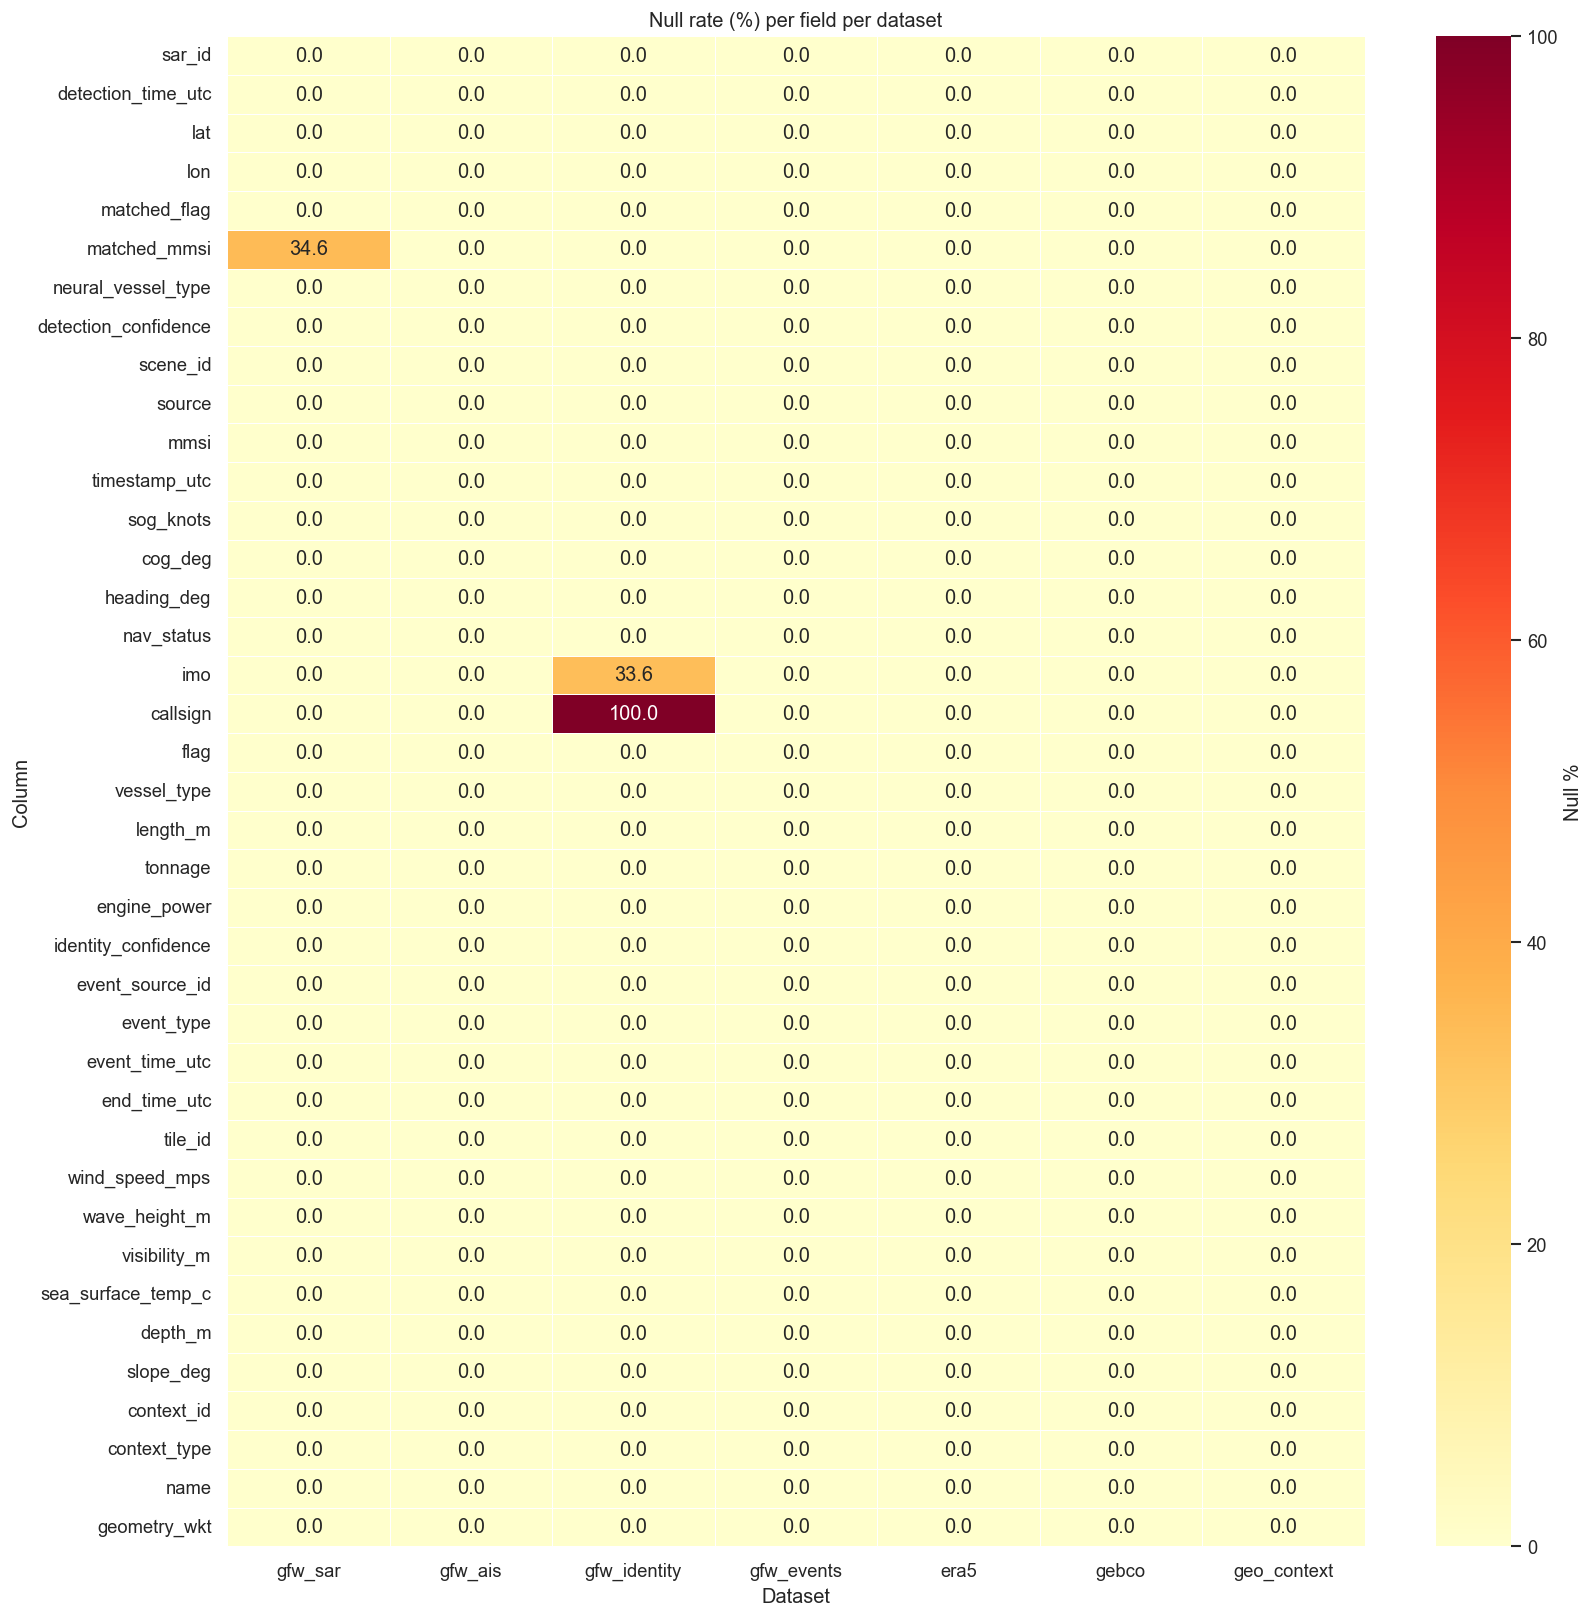

In [6]:
# ── Null rate per dataset ─────────────────────────────────────────────────────
null_frames = []
for name, df in datasets.items():
    nr = (df.isnull().mean() * 100).rename(name)
    null_frames.append(nr)
null_df = pd.concat(null_frames, axis=1).fillna(0)

fig, ax = plt.subplots(figsize=(14, max(4, len(null_df) * 0.35)))
sns.heatmap(null_df, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Null %'}, ax=ax)
ax.set(title='Null rate (%) per field per dataset',
       xlabel='Dataset', ylabel='Column')
plt.tight_layout()
plt.show()

In [7]:
# ── Out-of-range checks ───────────────────────────────────────────────────────
checks = {
    'SAR lat out of range [-90,90]':    (sar['lat'].abs() > 90).sum(),
    'SAR lon out of range [-180,180]':  (sar['lon'].abs() > 180).sum(),
    'AIS sog_knots > 50':               (ais['sog_knots'] > 50).sum(),
    'AIS lat out of range':             (ais['lat'].abs() > 90).sum(),
    'AIS duplicate (mmsi+timestamp)':   ais.duplicated(['mmsi','timestamp_utc']).sum(),
    'Identity duplicate MMSI':          identity.duplicated('mmsi').sum(),
    'GEBCO depth > 11000 m':            (gebco['depth_m'] > 11000).sum(),
    'ERA5 wind_speed < 0':              (era5['wind_speed_mps'] < 0).sum(),
    'SAR duplicate sar_id':             sar.duplicated('sar_id').sum(),
}

checks_df = pd.DataFrame.from_dict(checks, orient='index', columns=['count'])
checks_df['flag'] = checks_df['count'].apply(lambda x: '⚠️' if x > 0 else '✅')
print('Data quality checks:')
display(checks_df)

Data quality checks:


,count,flag
"SAR lat out of range [-90,90]",0,✅
"SAR lon out of range [-180,180]",0,✅
AIS sog_knots > 50,11,⚠️
AIS lat out of range,0,✅
AIS duplicate (mmsi+timestamp),0,✅
Identity duplicate MMSI,0,✅
GEBCO depth > 11000 m,0,✅
ERA5 wind_speed < 0,0,✅
SAR duplicate sar_id,0,✅


## 4. SAR Detection Overview

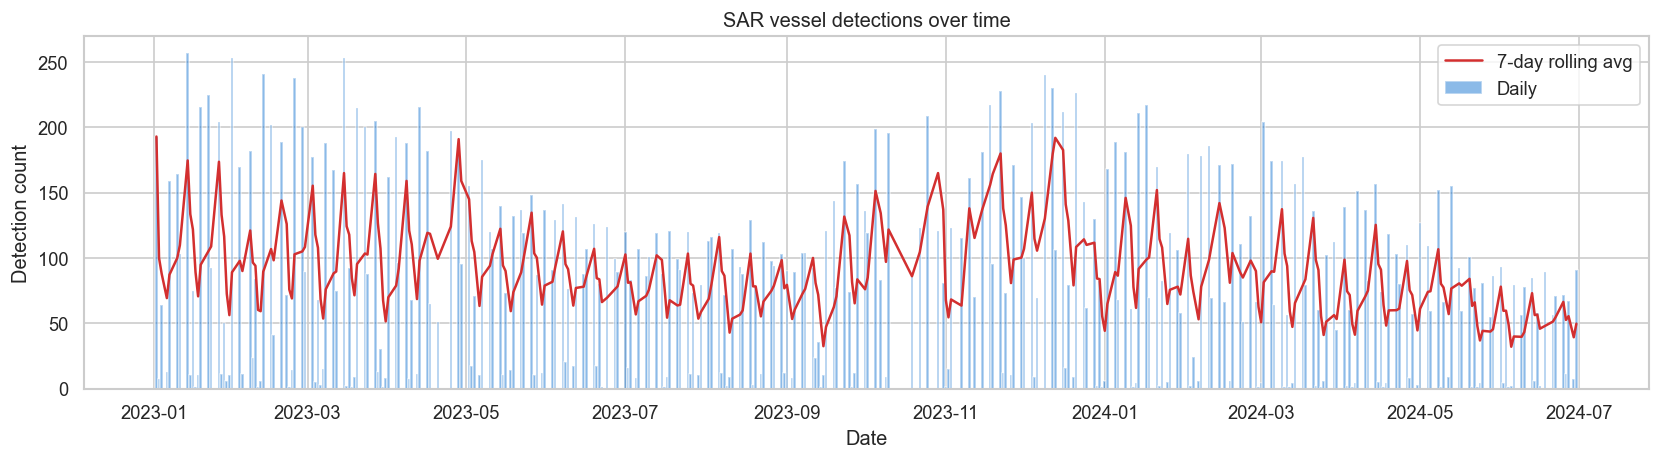

Date range : 2023-01-02 → 2024-06-30
Total detections : 27,574


In [8]:
# ── Daily detection counts ────────────────────────────────────────────────────
sar['date'] = sar['detection_time_utc'].dt.date
daily = sar.groupby('date').size().reset_index(name='detections')
daily['date'] = pd.to_datetime(daily['date'])
daily_7 = daily.set_index('date')['detections'].rolling('7D').mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(daily['date'], daily['detections'], color='#1976D2', alpha=0.5, width=1, label='Daily')
ax.plot(daily_7.index, daily_7.values, color='#D32F2F', linewidth=1.5, label='7-day rolling avg')
ax.set(title='SAR vessel detections over time', xlabel='Date', ylabel='Detection count')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Date range : {sar["detection_time_utc"].min().date()} → {sar["detection_time_utc"].max().date()}')
print(f'Total detections : {len(sar):,}')

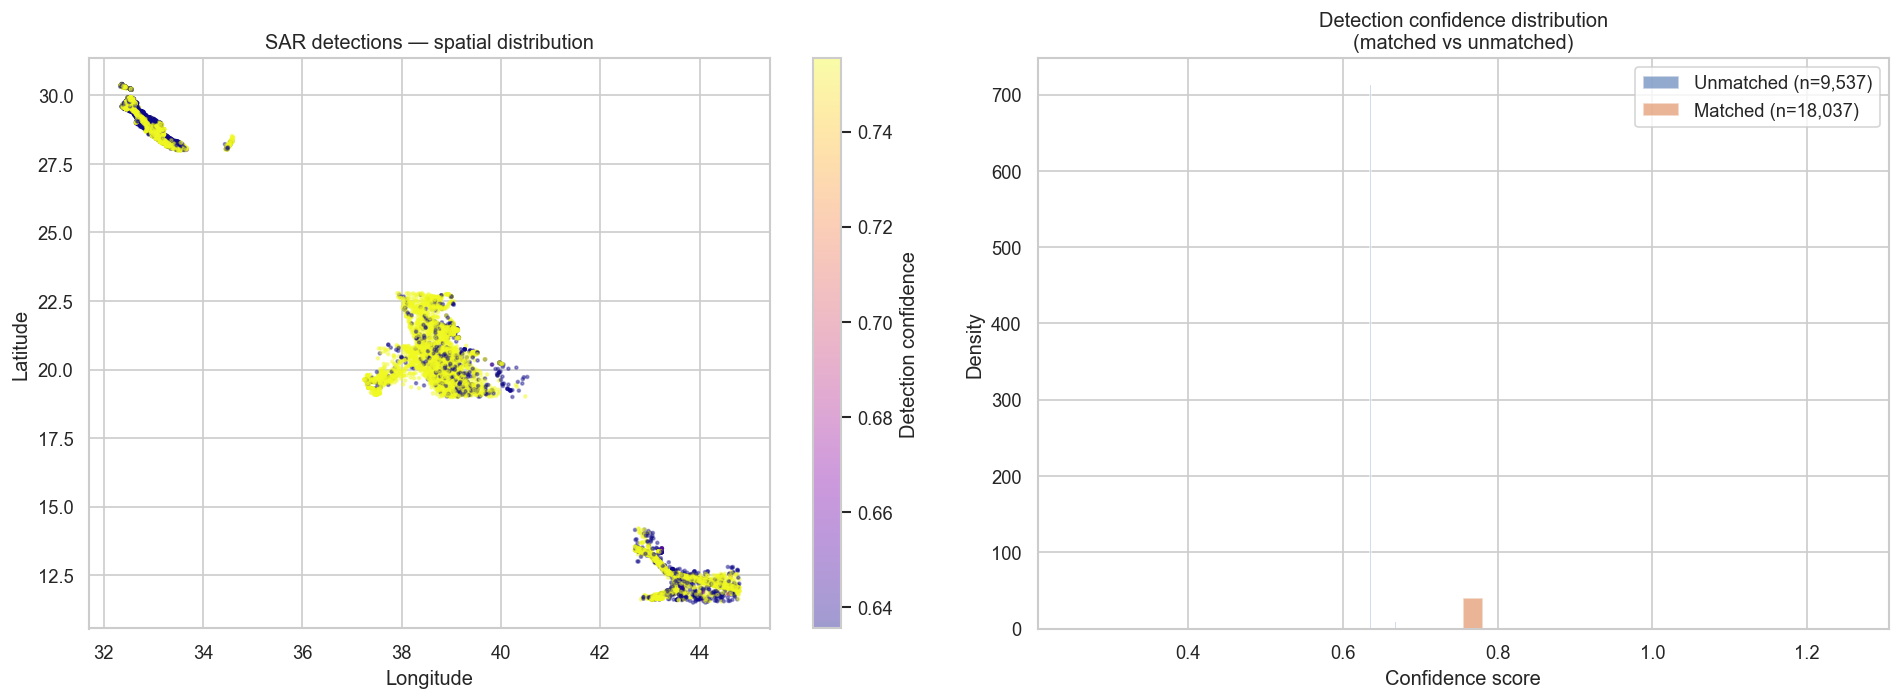


SAR match breakdown:
                  count   pct
matched_flag                 
Matched           18037  65.4
Unmatched (Dark)   9537  34.6


In [9]:
# ── Spatial map + confidence distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter map
sc = axes[0].scatter(
    sar['lon'], sar['lat'],
    c=sar['detection_confidence'], cmap='plasma',
    s=3, alpha=0.4, vmin=sar['detection_confidence'].quantile(0.01),
    vmax=sar['detection_confidence'].quantile(0.99)
)
plt.colorbar(sc, ax=axes[0], label='Detection confidence')
axes[0].set(title='SAR detections — spatial distribution',
             xlabel='Longitude', ylabel='Latitude')

# Confidence histogram split by matched flag
for flag, grp in sar.groupby('matched_flag'):
    label = f'{"Matched" if flag else "Unmatched"} (n={len(grp):,})'
    axes[1].hist(grp['detection_confidence'], bins=40, alpha=0.6,
                 density=True, label=label)
axes[1].set(title='Detection confidence distribution\n(matched vs unmatched)',
             xlabel='Confidence score', ylabel='Density')
axes[1].legend()

plt.tight_layout()
plt.show()

# Match rate summary
match_summary = sar['matched_flag'].value_counts().rename({True: 'Matched', False: 'Unmatched (Dark)'})
print('\nSAR match breakdown:')
print(match_summary.to_frame('count').assign(pct=lambda d: (d['count']/len(sar)*100).round(1)))

## 5. AIS Coverage and Temporal Analysis

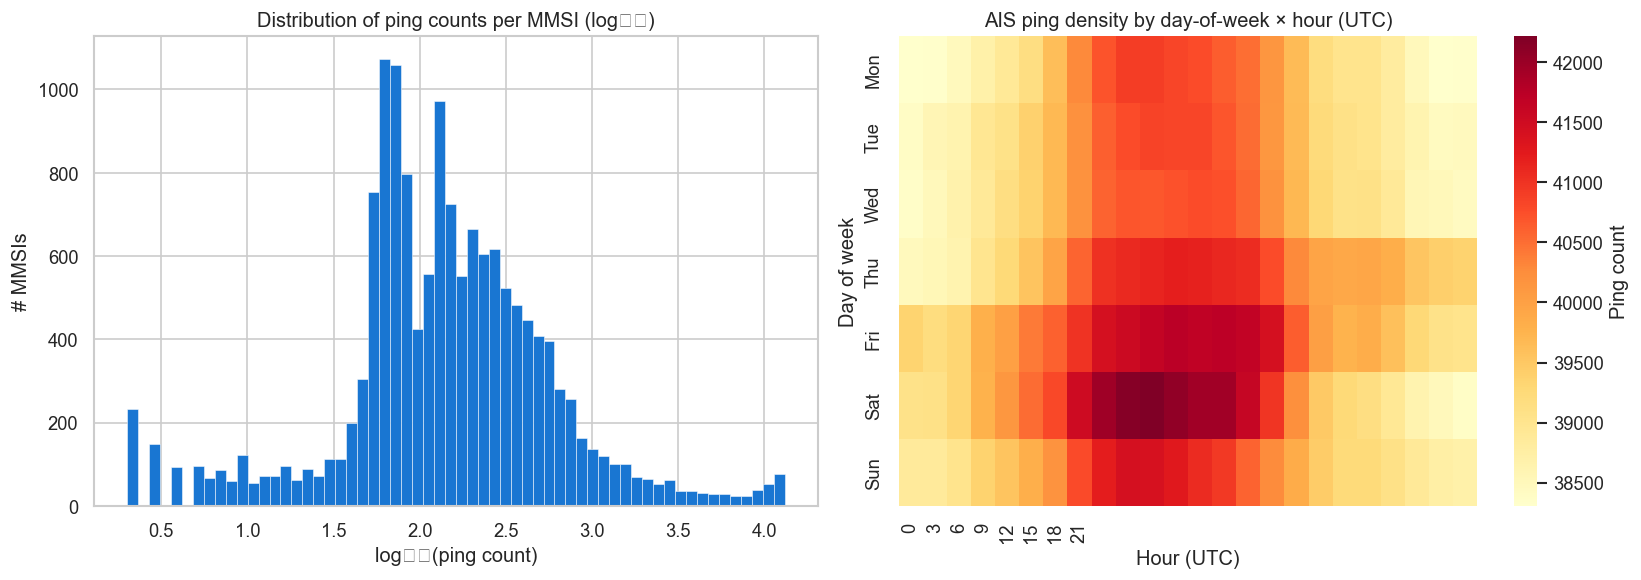

Unique MMSIs : 15,000
Median pings/MMSI : 133


In [10]:
# ── Per-MMSI ping counts ──────────────────────────────────────────────────────
ais_sorted = ais.sort_values(['mmsi', 'timestamp_utc'])
ping_counts = ais_sorted.groupby('mmsi').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(np.log10(ping_counts + 1), bins=60, color='#1976D2', edgecolor='white', linewidth=0.3)
axes[0].set(title='Distribution of ping counts per MMSI (log₁₀)',
             xlabel='log₁₀(ping count)', ylabel='# MMSIs')

# Hourly ping density
ais['hour'] = ais['timestamp_utc'].dt.hour
ais['dow']  = ais['timestamp_utc'].dt.dayofweek
pivot = ais.groupby(['dow', 'hour']).size().unstack(fill_value=0)
sns.heatmap(pivot, cmap='YlOrRd', ax=axes[1],
            cbar_kws={'label': 'Ping count'},
            xticklabels=range(0, 24, 3),
            yticklabels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[1].set(title='AIS ping density by day-of-week × hour (UTC)',
             xlabel='Hour (UTC)', ylabel='Day of week')

plt.tight_layout()
plt.show()

print(f'Unique MMSIs : {ais["mmsi"].nunique():,}')
print(f'Median pings/MMSI : {ping_counts.median():.0f}')

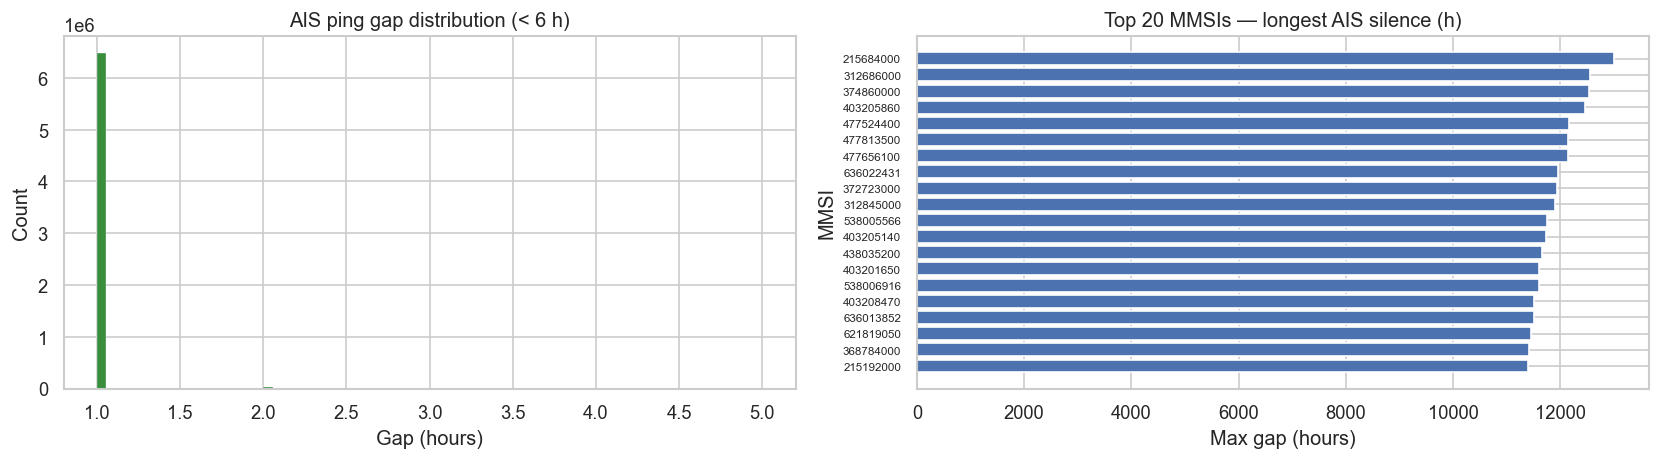

Gaps ≥ 12 h  : 114,064  (1.7% of transitions)
Gaps ≥ 24 h  : 88,664


In [11]:
# ── Within-MMSI temporal gap analysis ────────────────────────────────────────
ais_sorted = ais_sorted.reset_index(drop=True)
ais_sorted['next_ts'] = ais_sorted.groupby('mmsi')['timestamp_utc'].shift(-1)
ais_sorted['gap_h'] = (
    (ais_sorted['next_ts'] - ais_sorted['timestamp_utc'])
    .dt.total_seconds() / 3600
)
gaps = ais_sorted['gap_h'].dropna()
gaps = gaps[(gaps > 0) & (gaps < 24 * 30)]  # clip extreme

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(gaps[gaps < 6], bins=72, color='#388E3C', edgecolor='white', linewidth=0.2)
axes[0].set(title='AIS ping gap distribution (< 6 h)', xlabel='Gap (hours)', ylabel='Count')

# Long silence periods (>= 12 h gaps by MMSI)
long_gaps = ais_sorted[ais_sorted['gap_h'] >= 12].groupby('mmsi')['gap_h'].max().sort_values(ascending=False)
axes[1].barh(range(min(20, len(long_gaps))), long_gaps.head(20).values[::-1])
axes[1].set_yticks(range(min(20, len(long_gaps))))
axes[1].set_yticklabels([str(m) for m in long_gaps.head(20).index[::-1]], fontsize=7)
axes[1].set(title='Top 20 MMSIs — longest AIS silence (h)',
             xlabel='Max gap (hours)', ylabel='MMSI')

plt.tight_layout()
plt.show()

print(f'Gaps ≥ 12 h  : {(gaps >= 12).sum():,}  ({(gaps >= 12).mean()*100:.1f}% of transitions)')
print(f'Gaps ≥ 24 h  : {(gaps >= 24).sum():,}')

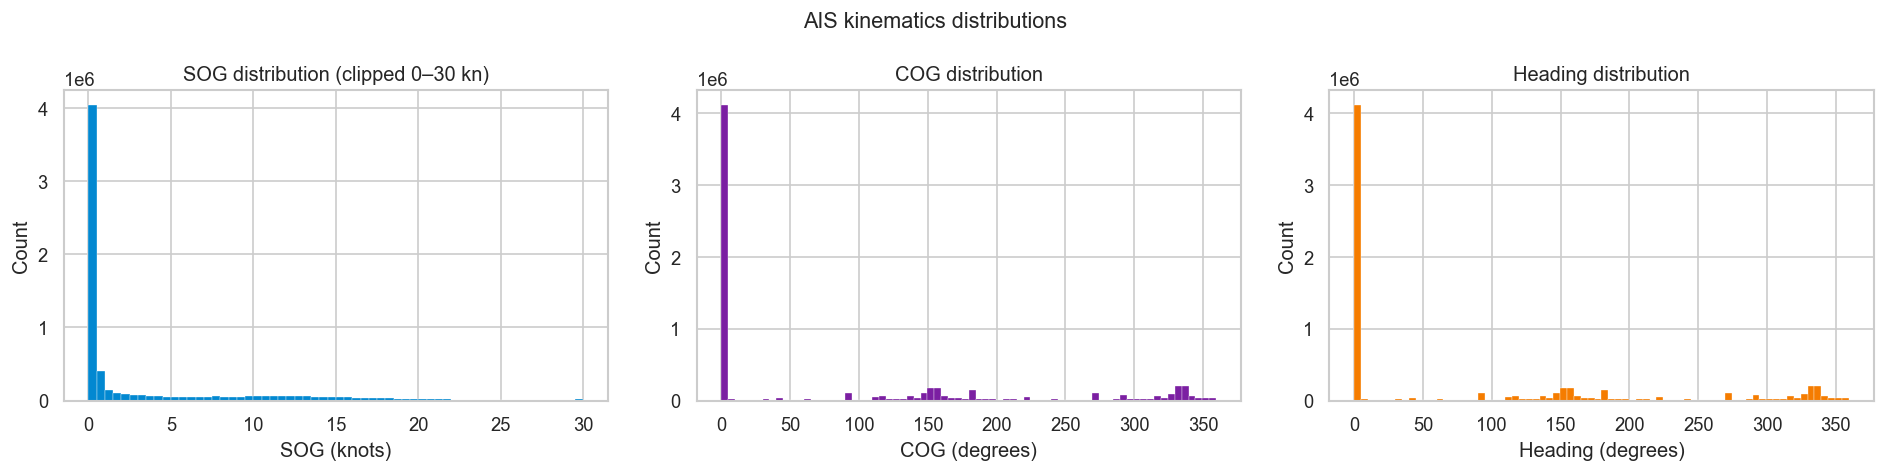

SOG summary (knots):
count    6703046.00
mean           3.40
std            6.07
min            0.00
25%            0.00
50%            0.00
75%            4.24
max           60.00


In [12]:
# ── SOG / COG / heading distributions ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sog_clip = ais['sog_knots'].clip(0, 30)
axes[0].hist(sog_clip, bins=60, color='#0288D1', edgecolor='white', linewidth=0.2)
axes[0].set(title='SOG distribution (clipped 0–30 kn)', xlabel='SOG (knots)', ylabel='Count')

axes[1].hist(ais['cog_deg'].dropna(), bins=72, color='#7B1FA2', edgecolor='white', linewidth=0.2)
axes[1].set(title='COG distribution', xlabel='COG (degrees)', ylabel='Count')

axes[2].hist(ais['heading_deg'].dropna(), bins=72, color='#F57C00', edgecolor='white', linewidth=0.2)
axes[2].set(title='Heading distribution', xlabel='Heading (degrees)', ylabel='Count')

plt.suptitle('AIS kinematics distributions', fontsize=13)
plt.tight_layout()
plt.show()

print('SOG summary (knots):')
print(ais['sog_knots'].describe().round(2).to_string())

## 6. Vessel Identity & Fleet Profiling

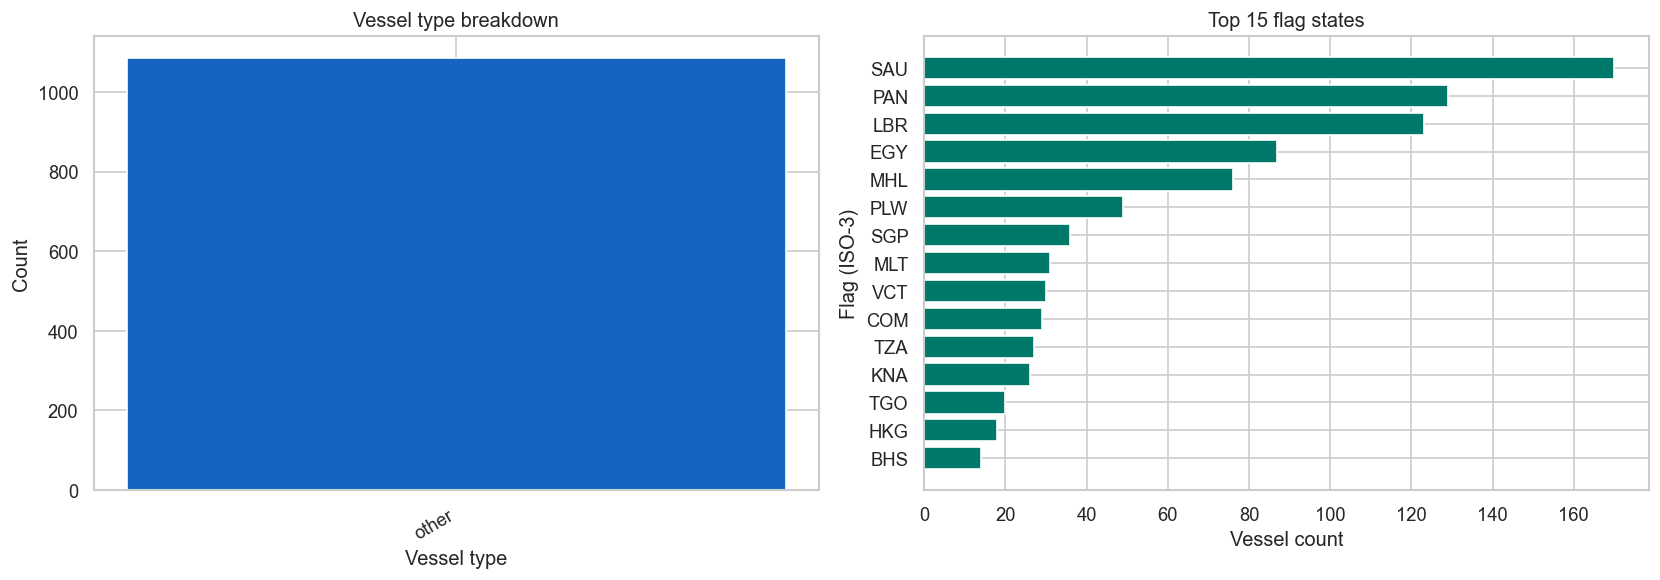

In [13]:
# ── vessel_type and flag distributions ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vtype = identity['vessel_type'].value_counts()
axes[0].bar(vtype.index, vtype.values, color='#1565C0')
axes[0].set(title='Vessel type breakdown', xlabel='Vessel type', ylabel='Count')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')

flag_top = identity['flag'].value_counts().head(15)
axes[1].barh(flag_top.index[::-1], flag_top.values[::-1], color='#00796B')
axes[1].set(title='Top 15 flag states', xlabel='Vessel count', ylabel='Flag (ISO-3)')

plt.tight_layout()
plt.show()

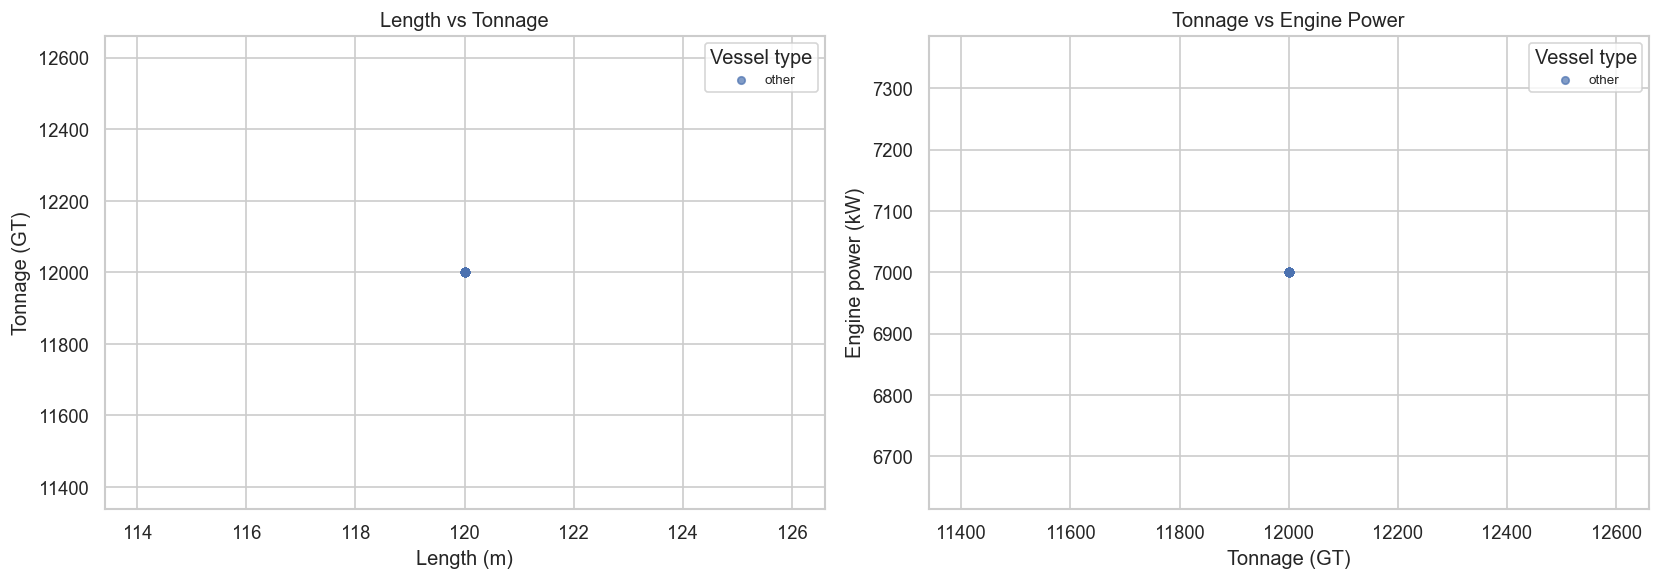

Identity summary stats:


,length_m,tonnage,engine_power,identity_confidence
count,1086.0,1086.0,1086.0,1086.0
mean,120.0,12000.0,7000.0,0.8
std,0.0,0.0,0.0,0.0
min,120.0,12000.0,7000.0,0.7
25%,120.0,12000.0,7000.0,0.7
50%,120.0,12000.0,7000.0,0.8
75%,120.0,12000.0,7000.0,0.8
max,120.0,12000.0,7000.0,0.8


In [14]:
# ── Physical characteristics scatter ─────────────────────────────────────────
id_clean = identity.dropna(subset=['length_m', 'tonnage', 'engine_power'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for vt, grp in id_clean.groupby('vessel_type'):
    axes[0].scatter(grp['length_m'], grp['tonnage'],
                    s=20, alpha=0.7, label=vt)
axes[0].set(title='Length vs Tonnage', xlabel='Length (m)', ylabel='Tonnage (GT)')
axes[0].legend(fontsize=8, title='Vessel type')

for vt, grp in id_clean.groupby('vessel_type'):
    axes[1].scatter(grp['tonnage'], grp['engine_power'],
                    s=20, alpha=0.7, label=vt)
axes[1].set(title='Tonnage vs Engine Power', xlabel='Tonnage (GT)', ylabel='Engine power (kW)')
axes[1].legend(fontsize=8, title='Vessel type')

plt.tight_layout()
plt.show()

print('Identity summary stats:')
display(identity[['length_m','tonnage','engine_power','identity_confidence']].describe().round(1))

## 7. SAR–AIS Matching Analysis

Overall SAR–AIS match rate: 65.4%


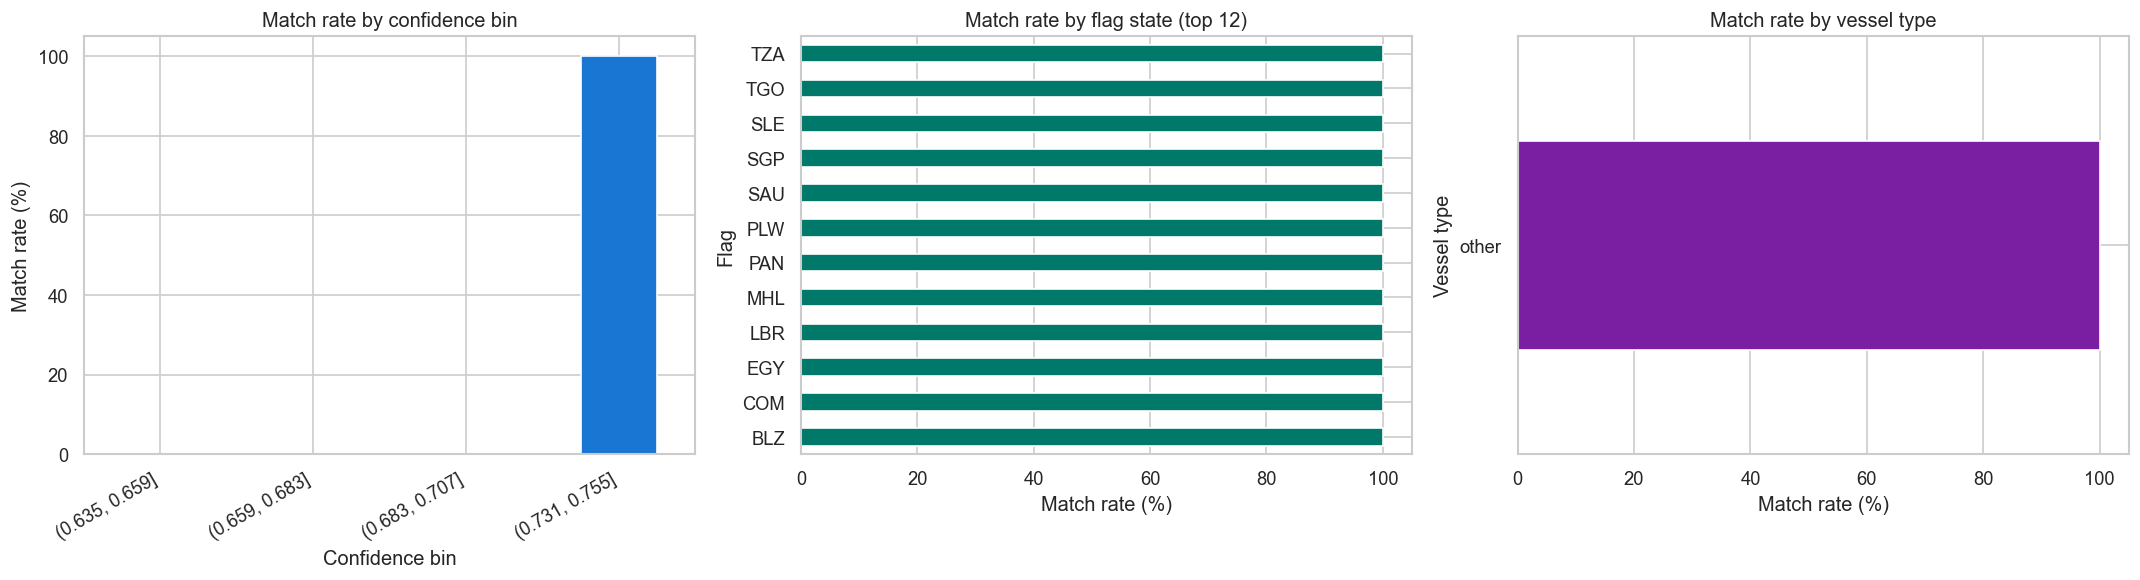

In [15]:
# ── Overall match rate ────────────────────────────────────────────────────────
match_rate = sar['matched_flag'].mean() * 100
print(f'Overall SAR–AIS match rate: {match_rate:.1f}%')

# Join identity to matched SAR
sar_id = sar.merge(identity[['mmsi','flag','vessel_type']],
                   left_on='matched_mmsi', right_on='mmsi', how='left')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Match rate by detection_confidence bin
sar_id['conf_bin'] = pd.cut(sar_id['detection_confidence'], bins=5)
mr_conf = sar_id.groupby('conf_bin', observed=True)['matched_flag'].mean() * 100
mr_conf.plot(kind='bar', ax=axes[0], color='#1976D2', edgecolor='white')
axes[0].set(title='Match rate by confidence bin',
             xlabel='Confidence bin', ylabel='Match rate (%)')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')

# Match rate by flag (top 12 flags)
top_flags = sar_id.dropna(subset=['flag'])['flag'].value_counts().head(12).index
mr_flag = (sar_id[sar_id['flag'].isin(top_flags)]
           .groupby('flag')['matched_flag'].mean() * 100).sort_values()
mr_flag.plot(kind='barh', ax=axes[1], color='#00796B', edgecolor='white')
axes[1].set(title='Match rate by flag state (top 12)',
             xlabel='Match rate (%)', ylabel='Flag')

# Match rate by vessel_type
mr_vtype = sar_id.dropna(subset=['vessel_type']).groupby('vessel_type')['matched_flag'].mean() * 100
mr_vtype.sort_values().plot(kind='barh', ax=axes[2], color='#7B1FA2', edgecolor='white')
axes[2].set(title='Match rate by vessel type',
             xlabel='Match rate (%)', ylabel='Vessel type')

plt.tight_layout()
plt.show()

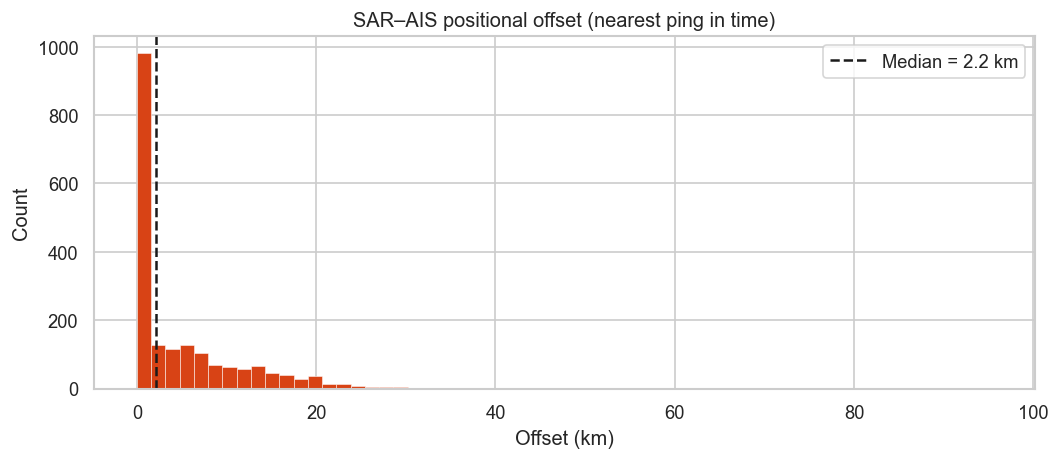

Median offset : 2.17 km
Offsets < 5 km: 64.2%


In [16]:
# ── Spatial offset: SAR position vs nearest AIS ping at detection time ────────
# For matched detections, find AIS ping closest in time to detection
matched_sar = sar[sar['matched_flag'] & sar['matched_mmsi'].notna()].copy()
matched_sar['matched_mmsi'] = matched_sar['matched_mmsi'].astype('Int64')

# Sample for performance (up to 2000 detections)
sample = matched_sar.sample(min(2000, len(matched_sar)), random_state=42)

offsets_km = []
for _, row in sample.iterrows():
    vessel_ais = ais[ais['mmsi'] == row['matched_mmsi']]
    if vessel_ais.empty:
        continue
    dt = (vessel_ais['timestamp_utc'] - row['detection_time_utc']).abs()
    nearest = vessel_ais.loc[dt.idxmin()]
    dlat = nearest['lat'] - row['lat']
    dlon = nearest['lon'] - row['lon']
    # Approximate km offset
    dist = np.sqrt((dlat * 111.32)**2 + (dlon * 111.32 * np.cos(np.radians(row['lat'])))**2)
    offsets_km.append(dist)

offsets_km = np.array(offsets_km)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(offsets_km[offsets_km < 100], bins=60, color='#D84315', edgecolor='white', linewidth=0.3)
ax.axvline(np.median(offsets_km), color='k', linestyle='--', label=f'Median = {np.median(offsets_km):.1f} km')
ax.set(title='SAR–AIS positional offset (nearest ping in time)',
        xlabel='Offset (km)', ylabel='Count')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Median offset : {np.median(offsets_km):.2f} km')
print(f'Offsets < 5 km: {(offsets_km < 5).mean()*100:.1f}%')

## 8. Event Feed Analysis (AIS Gaps)

Event type breakdown:
event_type
AIS_GAP    131365


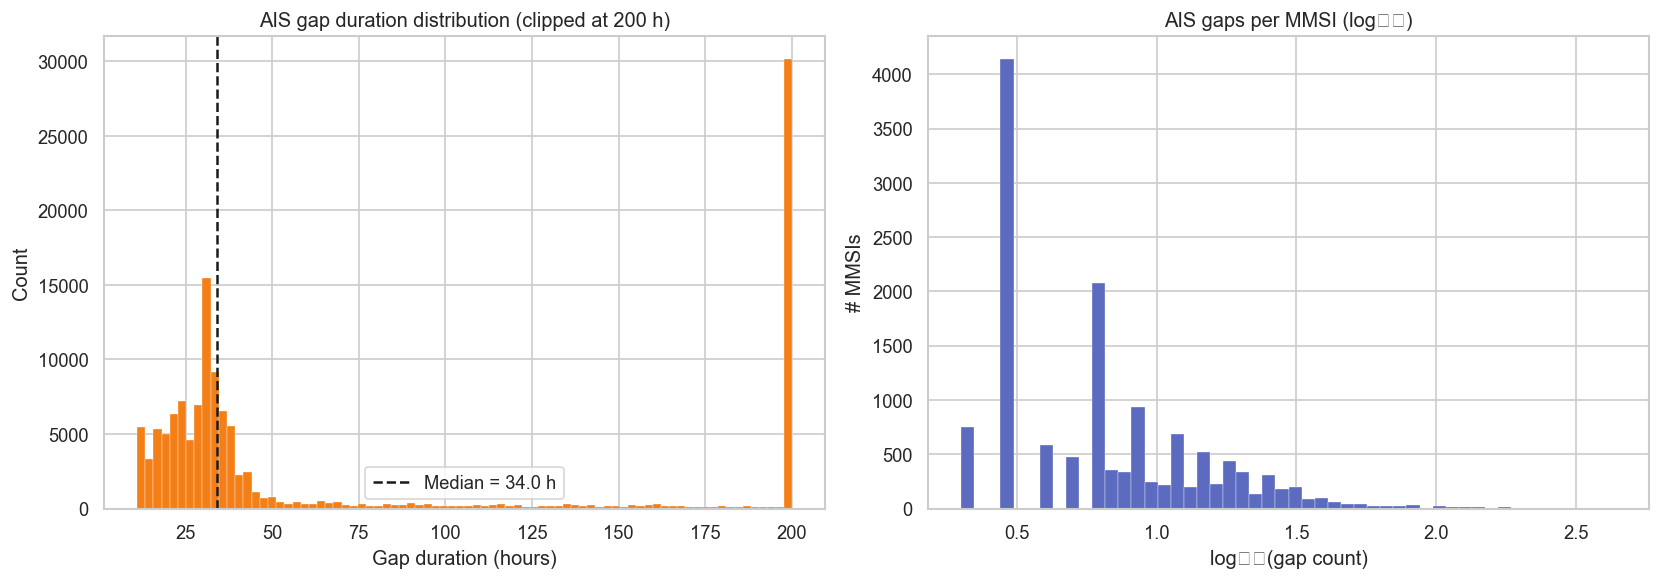


Total AIS gap events : 131,365
Unique MMSIs with gaps : 13,846
Median gap duration : 34.0 h
Gaps > 24 h : 100,907 (76.8%)


In [25]:
# ── Gap duration distribution ─────────────────────────────────────────────────
events['duration_h'] = (events['end_time_utc'] - events['event_time_utc']).dt.total_seconds() / 3600

print('Event type breakdown:')
print(events['event_type'].value_counts().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dur_clip = events['duration_h'].clip(0, 200)
axes[0].hist(dur_clip, bins=80, color='#F57F17', edgecolor='white', linewidth=0.2)
axes[0].axvline(events['duration_h'].median(), color='k', linestyle='--',
                 label=f'Median = {events["duration_h"].median():.1f} h')
axes[0].set(title='AIS gap duration distribution (clipped at 200 h)',
             xlabel='Gap duration (hours)', ylabel='Count')
axes[0].legend()

# Gaps per MMSI
gaps_per_mmsi = events.groupby('mmsi').size()
axes[1].hist(np.log10(gaps_per_mmsi + 1), bins=50, color='#5C6BC0', edgecolor='white', linewidth=0.2)
axes[1].set(title='AIS gaps per MMSI (log₁₀)', xlabel='log₁₀(gap count)', ylabel='# MMSIs')

plt.tight_layout()
plt.show()

print(f'\nTotal AIS gap events : {len(events):,}')
print(f'Unique MMSIs with gaps : {events["mmsi"].nunique():,}')
print(f'Median gap duration : {events["duration_h"].median():.1f} h')
print(f'Gaps > 24 h : {(events["duration_h"] > 24).sum():,} ({(events["duration_h"] > 24).mean()*100:.1f}%)')

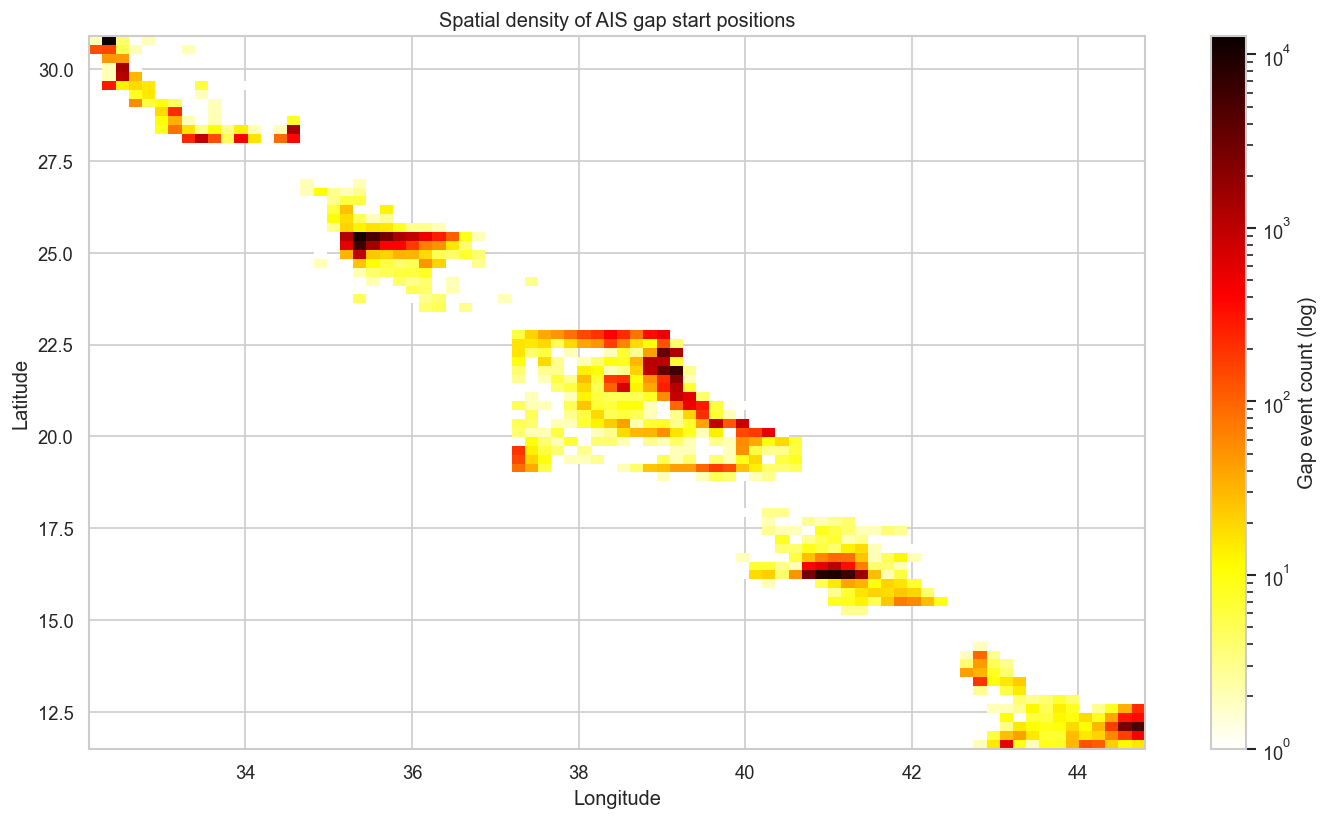

In [26]:
# ── Spatial density of AIS gap start positions ───────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
h = ax.hist2d(
    events['lon'], events['lat'],
    bins=80, cmap='hot_r',
    norm=mcolors.LogNorm()
)
plt.colorbar(h[3], ax=ax, label='Gap event count (log)')
ax.set(title='Spatial density of AIS gap start positions',
        xlabel='Longitude', ylabel='Latitude')
plt.tight_layout()
plt.show()

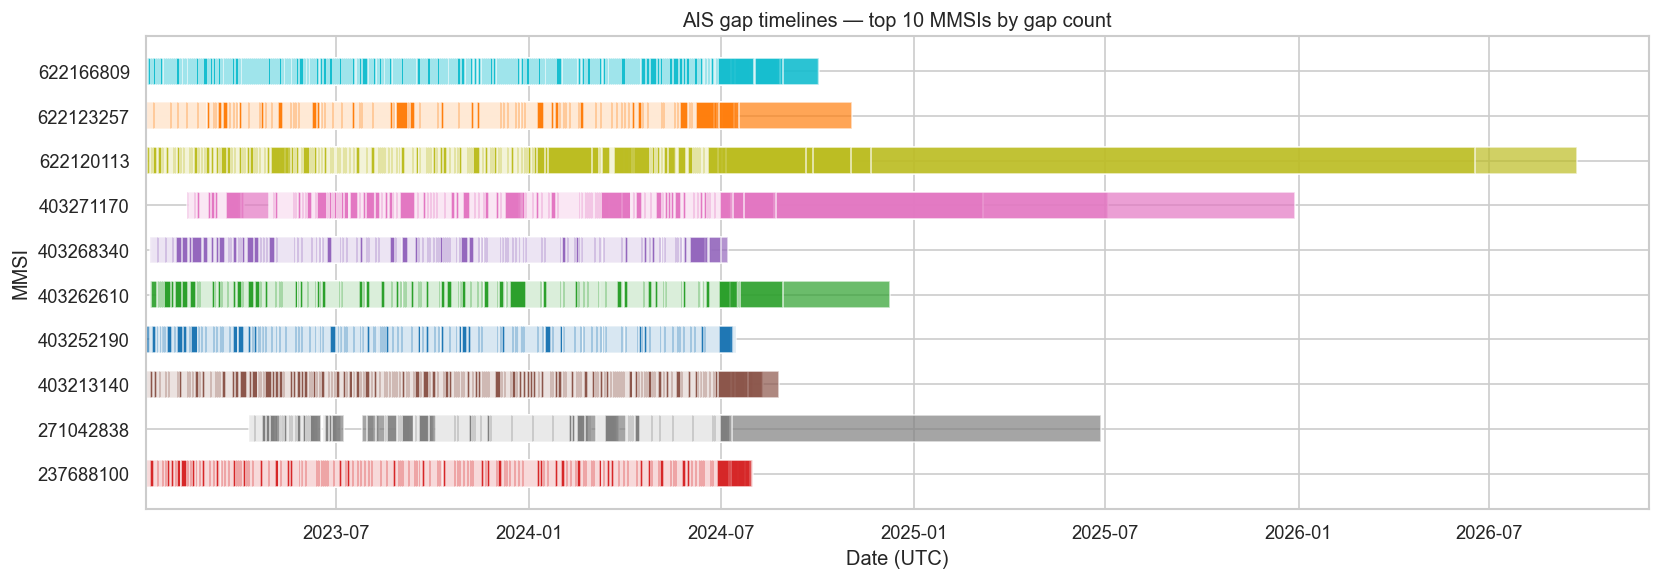

In [19]:
# ── Gap events timeline — sample of 10 high-gap MMSIs ─────────────────────────
top_mmsi = gaps_per_mmsi.nlargest(10).index.tolist()
ev_sample = events[events['mmsi'].isin(top_mmsi)].copy()
ev_sample['mmsi_str'] = ev_sample['mmsi'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
colors_ev = plt.cm.tab10(np.linspace(0, 1, len(top_mmsi)))
mmsi_color = {str(m): c for m, c in zip(top_mmsi, colors_ev)}

for i, (_, row) in enumerate(ev_sample.iterrows()):
    ax.barh(row['mmsi_str'],
            (row['end_time_utc'] - row['event_time_utc']).total_seconds() / 3600,
            left=row['event_time_utc'],
            height=0.6, color=mmsi_color[row['mmsi_str']], alpha=0.7)

ax.set(title='AIS gap timelines — top 10 MMSIs by gap count',
        xlabel='Date (UTC)', ylabel='MMSI')
plt.tight_layout()
plt.show()

## 9. Spatial Join: Environmental Context (ERA5 + GEBCO)

In [20]:
# ── Nearest-tile join using cKDTree ───────────────────────────────────────────
# ERA5 — use first timestamp snapshot as representative tile grid
era5_snap = era5.groupby(['lat','lon']).first().reset_index()

def nearest_join(source_df, tile_df, tile_cols, prefix=''):
    """Join source lat/lon to the nearest tile in tile_df."""
    tree = cKDTree(tile_df[['lat','lon']].values)
    _, idx = tree.query(source_df[['lat','lon']].values, k=1, workers=-1)
    out = source_df.copy()
    for col in tile_cols:
        out[prefix + col] = tile_df[col].iloc[idx].values
    return out

# Join ERA5 to SAR
sar_env = nearest_join(sar, era5_snap,
                        ['wind_speed_mps','wave_height_m','visibility_m','sea_surface_temp_c'])

# Join GEBCO to SAR
sar_env = nearest_join(sar_env, gebco, ['depth_m','slope_deg'])

print(f'SAR enriched shape: {sar_env.shape}')
display(sar_env[['detection_confidence','wind_speed_mps','wave_height_m',
                  'visibility_m','sea_surface_temp_c','depth_m','slope_deg']].describe().round(2))

SAR enriched shape: (27574, 17)


,detection_confidence,wind_speed_mps,wave_height_m,visibility_m,sea_surface_temp_c,depth_m,slope_deg
count,27574.00,27574.00,27574.00,27574.00,27574.00,27574.00,27574.00
mean,0.71,6.67,0.93,9526.69,23.15,-218.10,0.25
std,0.06,2.05,0.51,4010.01,2.92,374.21,0.40
min,0.64,1.33,0.39,5000.00,19.65,-2260.00,0.00
25%,0.64,6.14,0.65,6903.38,21.16,-148.00,0.05
50%,0.76,6.14,0.65,6903.38,21.16,-57.00,0.06
75%,0.76,7.00,1.07,12182.31,26.80,-40.00,0.28
max,0.76,12.14,2.59,19550.02,29.18,-1.00,2.13


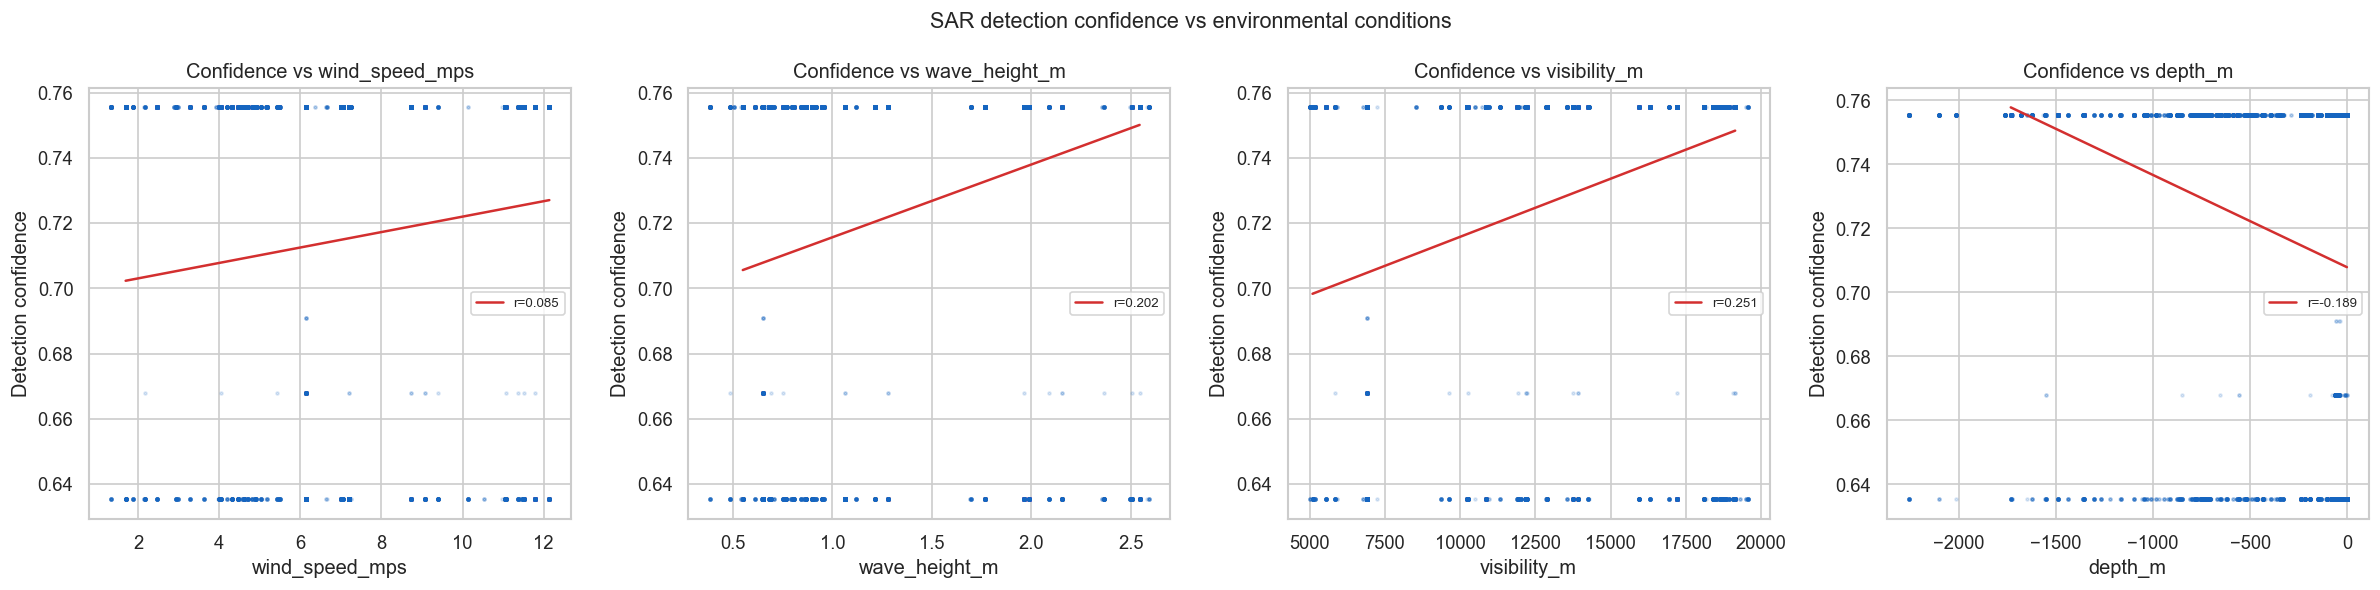

In [21]:
# ── Scatter plots: confidence vs environmental variables ─────────────────────
ENV_VARS = ['wind_speed_mps', 'wave_height_m', 'visibility_m', 'depth_m']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, var in zip(axes, ENV_VARS):
    x = sar_env[var].dropna()
    y = sar_env.loc[x.index, 'detection_confidence']
    ax.scatter(x, y, s=3, alpha=0.15, color='#1565C0')
    # Regression line
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xr = np.linspace(x.quantile(0.01), x.quantile(0.99), 100)
    ax.plot(xr, slope * xr + intercept, color='#D32F2F', linewidth=1.5,
             label=f'r={r:.3f}')
    ax.set(title=f'Confidence vs {var}', xlabel=var, ylabel='Detection confidence')
    ax.legend(fontsize=8)

plt.suptitle('SAR detection confidence vs environmental conditions', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Geo-Context: Ports, Chokepoints, and Coastal Proximity

In [22]:
# ── Port and chokepoint proximity ────────────────────────────────────────────
ports       = geo[geo['context_type'] == 'port'][['name','lat','lon']].reset_index(drop=True)
chokepoints = geo[geo['context_type'] == 'chokepoint'][['name','lat','lon']].reset_index(drop=True)

print(f'Ports ({len(ports)}): {ports["name"].tolist()}')
print(f'Chokepoints ({len(chokepoints)}): {chokepoints["name"].tolist()}')

def dist_to_nearest_km(source_latlon, ref_latlon):
    """Haversine-approximate distance from each source point to nearest ref."""
    tree = cKDTree(ref_latlon)
    dists_deg, idx = tree.query(source_latlon, k=1)
    # Convert rough degrees → km (1° ≈ 111 km, rough)
    src = np.radians(source_latlon)
    ref = np.radians(ref_latlon[idx])
    dlat = src[:, 0] - ref[:, 0]
    dlon = src[:, 1] - ref[:, 1]
    a = np.sin(dlat/2)**2 + np.cos(src[:,0]) * np.cos(ref[:,0]) * np.sin(dlon/2)**2
    return 6371.0 * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1))), idx

sar_latlon = sar_env[['lat','lon']].values
dist_port, port_idx   = dist_to_nearest_km(sar_latlon, ports[['lat','lon']].values)
dist_choke, choke_idx = dist_to_nearest_km(sar_latlon, chokepoints[['lat','lon']].values)

sar_env['dist_port_km']       = dist_port
sar_env['nearest_port']       = ports['name'].iloc[port_idx].values
sar_env['dist_chokepoint_km'] = dist_choke
sar_env['nearest_chokepoint'] = chokepoints['name'].iloc[choke_idx].values

print('\nDistance to nearest port (km):')
print(sar_env['dist_port_km'].describe().round(1).to_string())

Ports (13): ['Damietta', 'Safaga', 'Tel Aviv Yafo', 'Assab', 'Massawa', 'Elat', 'Jizan', 'Djibouti', 'Port Sudan', 'Hodeidah', 'Jeddah', 'Aden', 'Port Said']
Chokepoints (3): ['bab_el_mandeb', 'strait_of_tiran', 'suez_south_approach']

Distance to nearest port (km):
count    27574.0
mean       148.3
std         67.9
min          0.0
25%        100.6
50%        168.4
75%        202.7
max        304.6


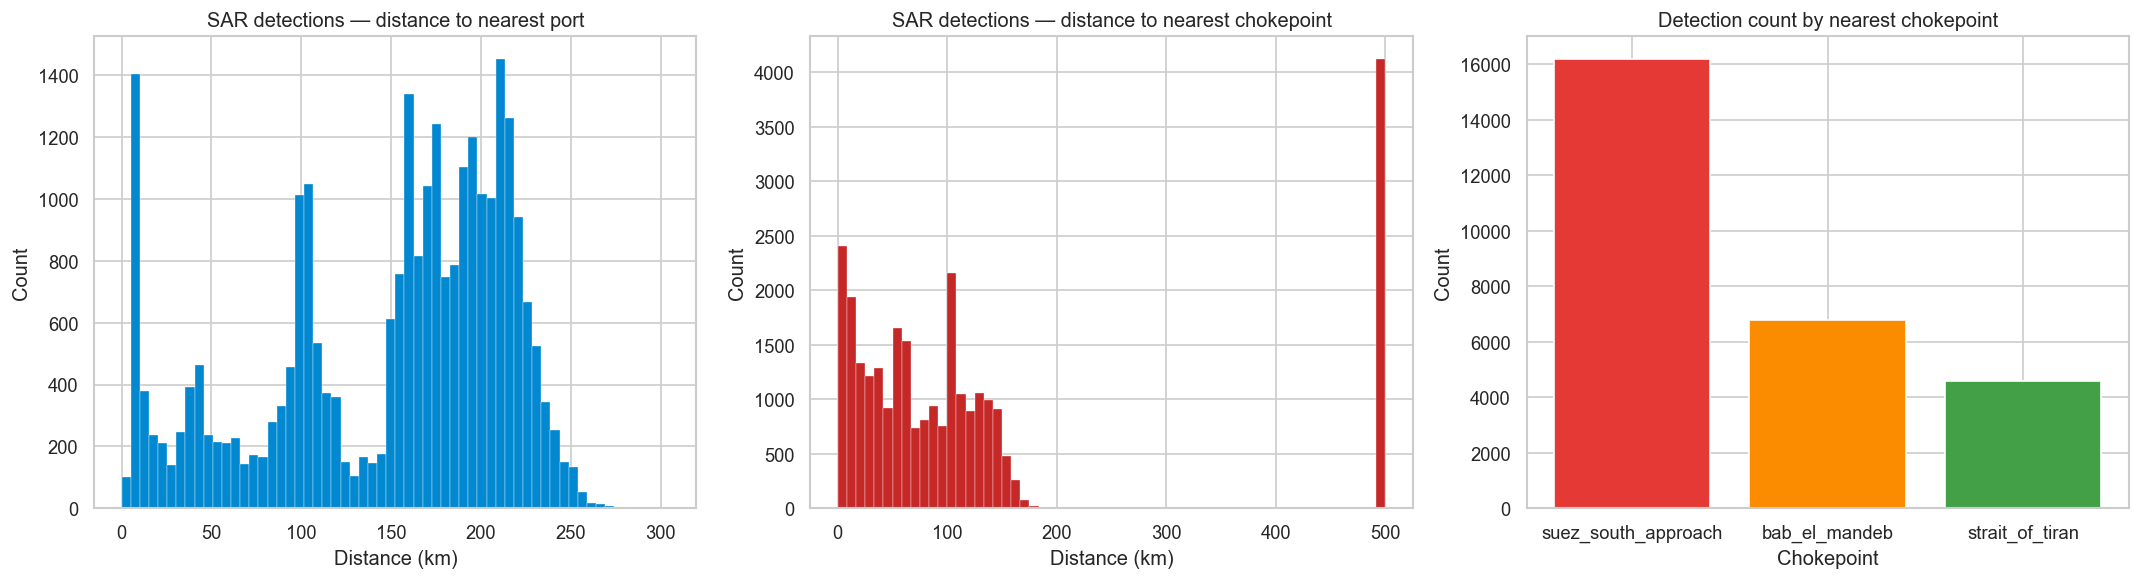


Detections within 50 km of a port: 3772
Detections within 50 km of a chokepoint: 9106


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Port distance histogram
axes[0].hist(sar_env['dist_port_km'].clip(0, 500), bins=60, color='#0288D1', edgecolor='white', linewidth=0.2)
axes[0].set(title='SAR detections — distance to nearest port',
             xlabel='Distance (km)', ylabel='Count')

# Chokepoint distance histogram
axes[1].hist(sar_env['dist_chokepoint_km'].clip(0, 500), bins=60, color='#C62828', edgecolor='white', linewidth=0.2)
axes[1].set(title='SAR detections — distance to nearest chokepoint',
             xlabel='Distance (km)', ylabel='Count')

# Detection density by chokepoint
cp_counts = sar_env['nearest_chokepoint'].value_counts()
axes[2].bar(cp_counts.index, cp_counts.values, color=['#E53935','#FB8C00','#43A047'])
axes[2].set(title='Detection count by nearest chokepoint',
             xlabel='Chokepoint', ylabel='Count')

plt.tight_layout()
plt.show()

print('\nDetections within 50 km of a port:', (sar_env['dist_port_km'] < 50).sum())
print('Detections within 50 km of a chokepoint:', (sar_env['dist_chokepoint_km'] < 50).sum())

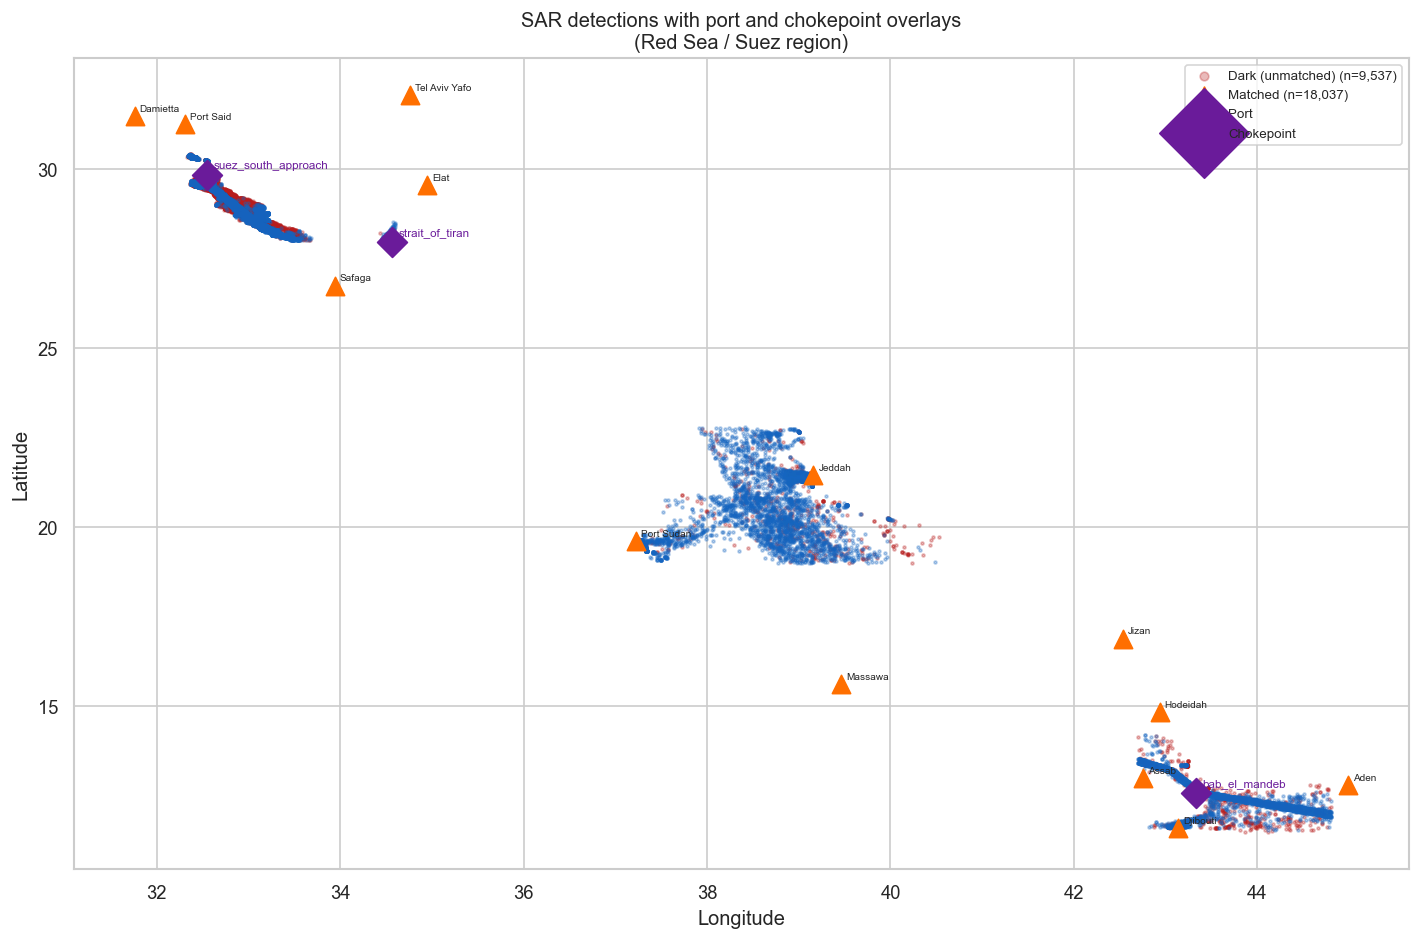

In [24]:
# ── Spatial map with port and chokepoint overlays ─────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

for flag, grp in sar_env.groupby('matched_flag'):
    label = f'{"Matched" if flag else "Dark (unmatched)"} (n={len(grp):,})'
    color = '#1565C0' if flag else '#B71C1C'
    ax.scatter(grp['lon'], grp['lat'], s=3, alpha=0.3, color=color, label=label)

ax.scatter(ports['lon'], ports['lat'], marker='^', s=120, color='#FF6F00',
            zorder=5, label='Port')
for _, p in ports.iterrows():
    ax.annotate(p['name'], (p['lon'], p['lat']),
                fontsize=6, xytext=(3, 3), textcoords='offset points')

ax.scatter(chokepoints['lon'], chokepoints['lat'], marker='D', s=160,
            color='#6A1B9A', zorder=6, label='Chokepoint')
for _, c in chokepoints.iterrows():
    ax.annotate(c['name'], (c['lon'], c['lat']),
                fontsize=7, xytext=(4, 4), textcoords='offset points', color='#6A1B9A')

ax.set(title='SAR detections with port and chokepoint overlays\n(Red Sea / Suez region)',
        xlabel='Longitude', ylabel='Latitude')
ax.legend(markerscale=3, fontsize=8)
plt.tight_layout()
plt.show()

## 11. Dark Vessel Detection
SAR detections with **no AIS match** (`matched_flag = False`) are "dark vessels" —
ships that are either not transmitting AIS or are actively suppressing it.

Dark vessels   : 9,537  (34.6%)
Matched vessels: 18,037  (65.4%)


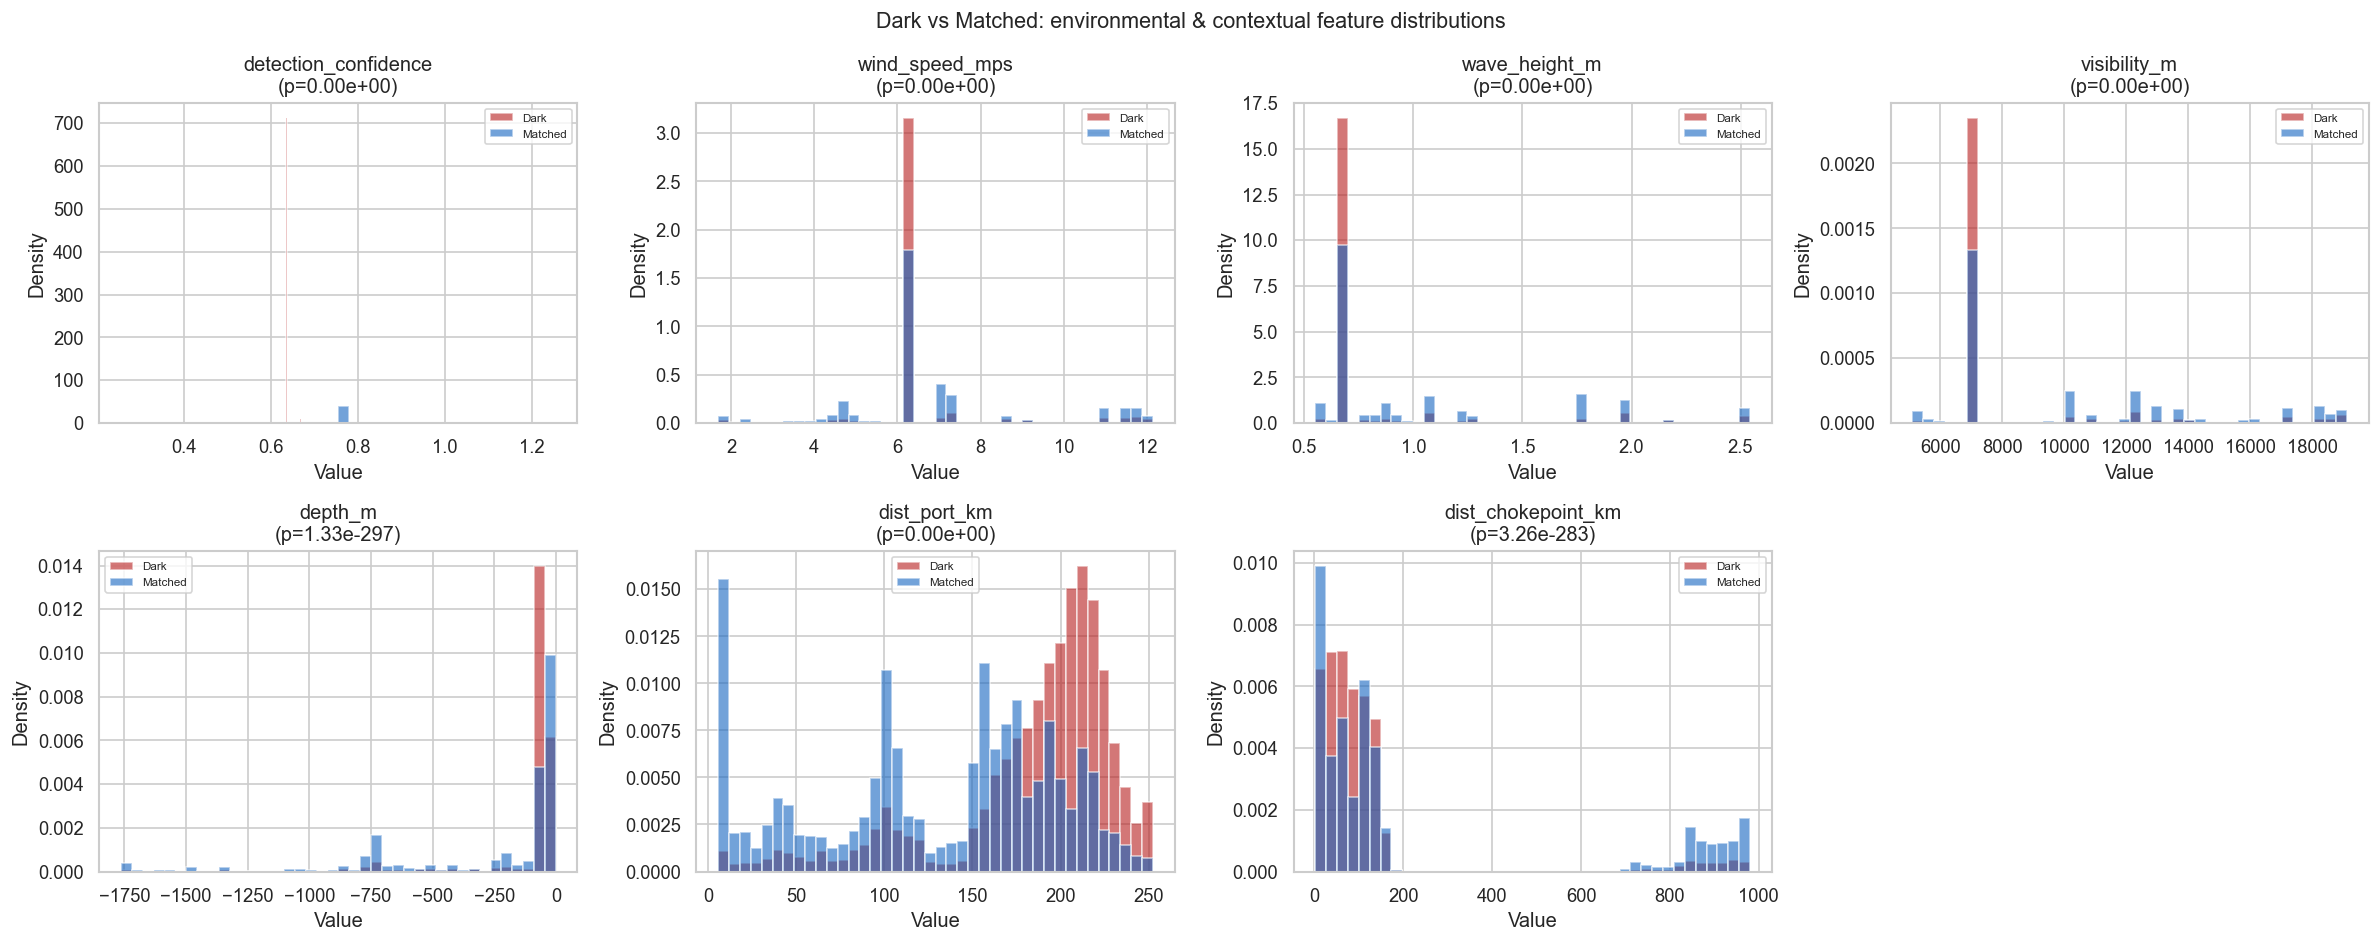

In [27]:
dark    = sar_env[~sar_env['matched_flag']].copy()
matched = sar_env[sar_env['matched_flag']].copy()

print(f'Dark vessels   : {len(dark):,}  ({len(dark)/len(sar_env)*100:.1f}%)')
print(f'Matched vessels: {len(matched):,}  ({len(matched)/len(sar_env)*100:.1f}%)')

# ── Compare environmental profiles ───────────────────────────────────────────
ENV_COMPARE = ['detection_confidence', 'wind_speed_mps', 'wave_height_m',
               'visibility_m', 'depth_m', 'dist_port_km', 'dist_chokepoint_km']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, feat in zip(axes.flat, ENV_COMPARE):
    d_vals = dark[feat].dropna()
    m_vals = matched[feat].dropna()
    lo = min(d_vals.quantile(0.01), m_vals.quantile(0.01))
    hi = max(d_vals.quantile(0.99), m_vals.quantile(0.99))
    ax.hist(d_vals.clip(lo, hi), bins=40, alpha=0.6, density=True,
             color='#B71C1C', label='Dark')
    ax.hist(m_vals.clip(lo, hi), bins=40, alpha=0.6, density=True,
             color='#1565C0', label='Matched')
    t, p = stats.ttest_ind(d_vals, m_vals, equal_var=False)
    ax.set(title=f'{feat}\n(p={p:.2e})', xlabel='Value', ylabel='Density')
    ax.legend(fontsize=7)

# Hide unused subplot
axes.flat[-1].set_visible(False)
plt.suptitle('Dark vs Matched: environmental & contextual feature distributions', fontsize=13)
plt.tight_layout()
plt.show()

In [28]:
# ── Statistical test summary ─────────────────────────────────────────────────
stat_rows = []
for feat in ENV_COMPARE:
    d_vals = dark[feat].dropna()
    m_vals = matched[feat].dropna()
    t, p = stats.ttest_ind(d_vals, m_vals, equal_var=False)
    stat_rows.append(dict(
        feature      = feat,
        dark_mean    = d_vals.mean(),
        matched_mean = m_vals.mean(),
        diff         = d_vals.mean() - m_vals.mean(),
        t_stat       = t,
        p_value      = p,
    ))

stat_df = pd.DataFrame(stat_rows)
stat_df['p_bonf'] = np.minimum(stat_df['p_value'] * len(ENV_COMPARE), 1.0)
stat_df['sig']    = stat_df['p_bonf'] < 0.05

print('Dark vs Matched Welch t-tests (Bonferroni corrected):')
display(stat_df.round(4).style
        .background_gradient(cmap='RdYlGn_r', subset=['p_bonf'])
        .applymap(lambda x: 'background-color: #FFCDD2' if x else '', subset=['sig']))

Dark vs Matched Welch t-tests (Bonferroni corrected):


AttributeError: 'Styler' object has no attribute 'applymap'

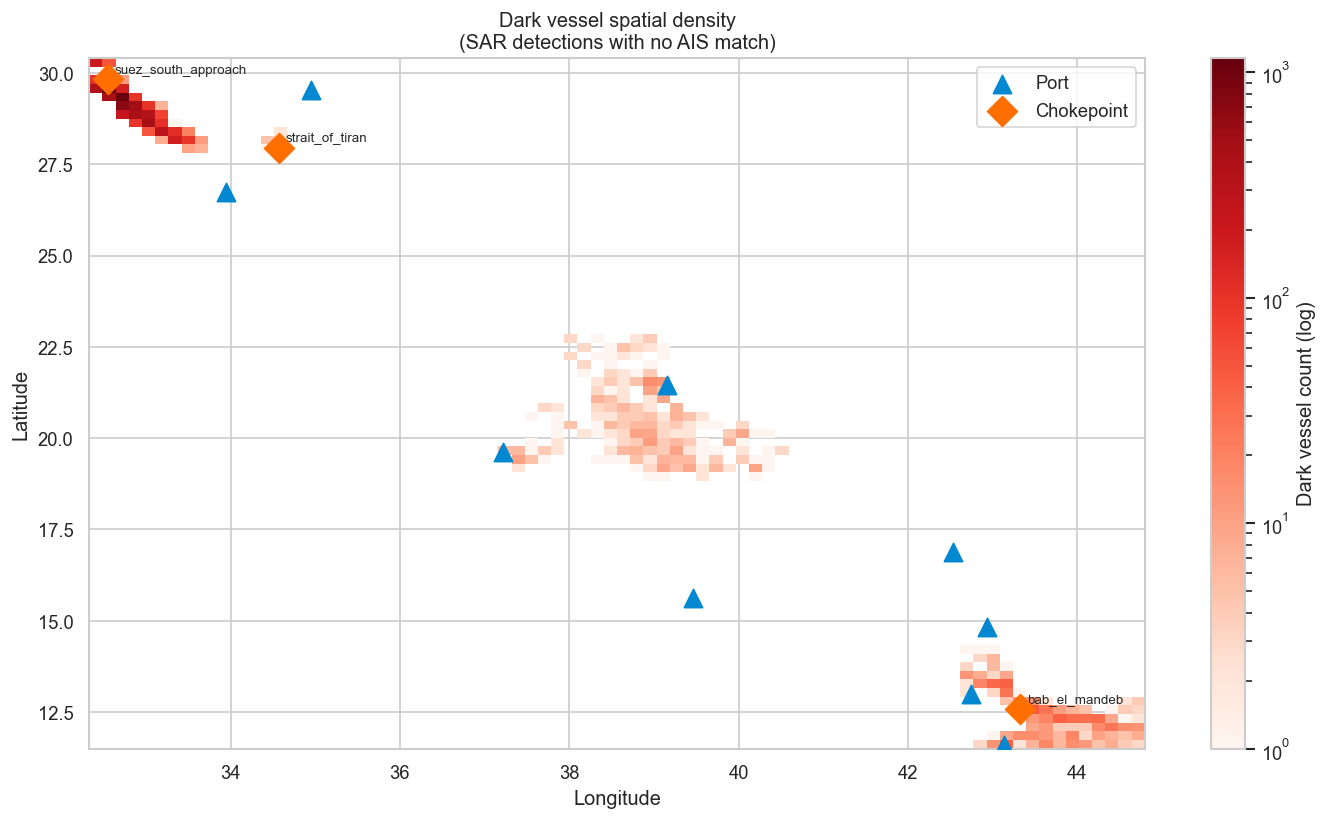

Dark vessel proximity summary:
  Median distance to port       : 199.4 km
  Median distance to chokepoint : 73.5 km
  Dark vessels within 20 km of chokepoint: 1103


In [29]:
# ── Dark vessel spatial density map ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
h = ax.hist2d(dark['lon'], dark['lat'], bins=80,
               cmap='Reds', norm=mcolors.LogNorm())
plt.colorbar(h[3], ax=ax, label='Dark vessel count (log)')

ax.scatter(ports['lon'], ports['lat'], marker='^', s=120, color='#0288D1',
            zorder=5, label='Port')
ax.scatter(chokepoints['lon'], chokepoints['lat'], marker='D', s=160,
            color='#FF6F00', zorder=6, label='Chokepoint')
for _, c in chokepoints.iterrows():
    ax.annotate(c['name'], (c['lon'], c['lat']),
                fontsize=8, xytext=(4, 4), textcoords='offset points')

ax.set(title='Dark vessel spatial density\n(SAR detections with no AIS match)',
        xlabel='Longitude', ylabel='Latitude')
ax.legend()
plt.tight_layout()
plt.show()

print('Dark vessel proximity summary:')
print(f'  Median distance to port       : {dark["dist_port_km"].median():.1f} km')
print(f'  Median distance to chokepoint : {dark["dist_chokepoint_km"].median():.1f} km')
print(f'  Dark vessels within 20 km of chokepoint: {(dark["dist_chokepoint_km"] < 20).sum()}')

## 12. Correlation: Detection Confidence vs Environmental Conditions

In [ ]:
# ── Feature matrix ────────────────────────────────────────────────────────────
FEAT_COLS = ['detection_confidence', 'wind_speed_mps', 'wave_height_m',
             'visibility_m', 'sea_surface_temp_c', 'depth_m', 'slope_deg',
             'dist_port_km', 'dist_chokepoint_km']

feat_df = sar_env[FEAT_COLS].dropna()
print(f'Feature matrix shape: {feat_df.shape}')

# Pearson and Spearman correlations with detection_confidence
corr_rows = []
for col in FEAT_COLS[1:]:
    pr, pp = stats.pearsonr(feat_df['detection_confidence'], feat_df[col])
    sr, sp = stats.spearmanr(feat_df['detection_confidence'], feat_df[col])
    corr_rows.append(dict(feature=col, pearson_r=pr, pearson_p=pp, spearman_r=sr, spearman_p=sp))

corr_tbl = pd.DataFrame(corr_rows).set_index('feature')
print('\nCorrelations with detection_confidence:')
display(corr_tbl.round(4).style.background_gradient(cmap='RdBu_r', subset=['pearson_r','spearman_r'], axis=0))

In [ ]:
# ── Clustermap ───────────────────────────────────────────────────────────────
corr_full = feat_df.corr(method='pearson')

g = sns.clustermap(corr_full, cmap='RdBu_r', center=0, linewidths=0.3,
                    figsize=(10, 10), annot=True, fmt='.2f',
                    cbar_kws={'label': 'Pearson r'})
g.figure.suptitle('Clustermap: pairwise Pearson correlations\n(detection confidence + environmental features)',
                   y=1.02, fontsize=12)
plt.show()

In [ ]:
# ── Random Forest feature importance for predicting detection_confidence ──────
X_rf = feat_df[FEAT_COLS[1:]].values
y_rf = feat_df['detection_confidence'].values

scaler_rf = StandardScaler()
X_rf_s    = scaler_rf.fit_transform(X_rf)

rf = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X_rf_s, y_rf)

importance = pd.Series(rf.feature_importances_, index=FEAT_COLS[1:]).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importance.plot(kind='barh', color='#1B5E20', ax=ax, edgecolor='white')
ax.set(title='Random Forest feature importance\n(predicting SAR detection_confidence)',
        xlabel='Importance', ylabel='Feature')
plt.tight_layout()
plt.show()

print(f'RF R² on training set: {rf.score(X_rf_s, y_rf):.4f}')
print('\nFeature importances:')
print(importance.sort_values(ascending=False).round(4).to_string())

## 13. PCA on SAR Detection Feature Space

Apply PCA to the per-detection feature matrix combining environmental conditions, bathymetry, and geo-context distances.
Colour points by **dark vs matched** status to see whether the two populations separate in principal-component space.

PCA feature matrix : (27574, 9)
Features           : ['wind_speed_mps', 'wave_height_m', 'visibility_m', 'sea_surface_temp_c', 'depth_m', 'slope_deg', 'dist_port_km', 'dist_chokepoint_km', 'detection_confidence']
Dark               : 9,537
Matched            : 18,037

Components for 90% variance: 5
Components for 95% variance: 6


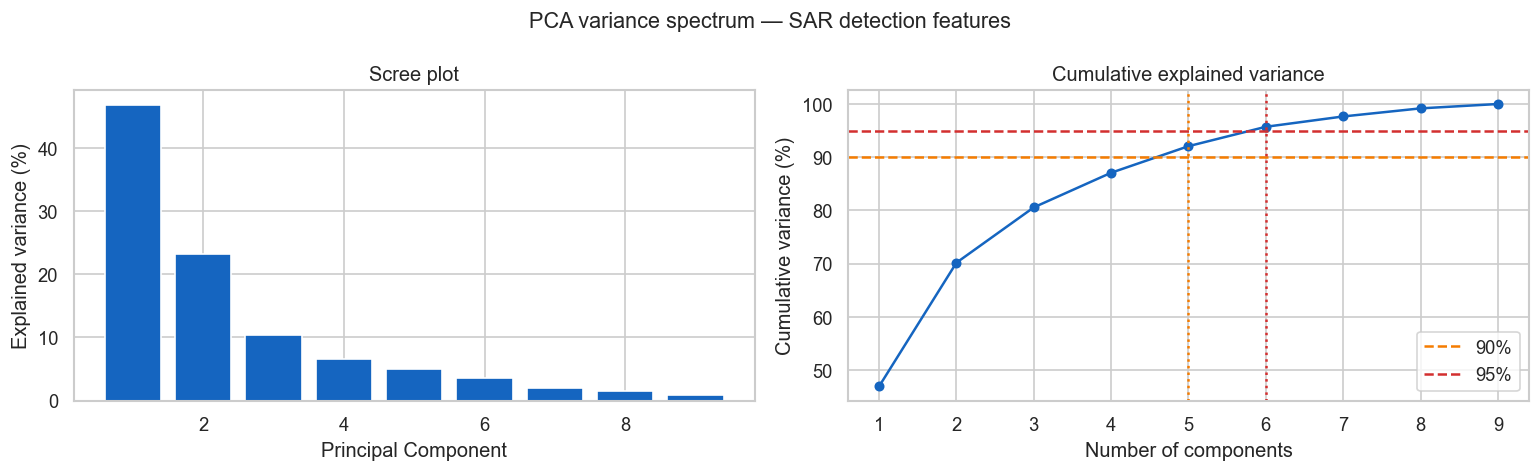

In [30]:
from sklearn.decomposition import PCA

# ── CONFIG ─────────────────────────────────────────────────────────────────────
PCA_FEATURES = [
    'wind_speed_mps', 'wave_height_m', 'visibility_m', 'sea_surface_temp_c',
    'depth_m', 'slope_deg', 'dist_port_km', 'dist_chokepoint_km',
    'detection_confidence',
]

# ── Build clean feature matrix ────────────────────────────────────────────────
pca_df = sar_env[PCA_FEATURES + ['matched_flag']].dropna().reset_index(drop=True)
X_raw  = pca_df[PCA_FEATURES].values
labels_pca = pca_df['matched_flag'].map({True: 'Matched', False: 'Dark'}).values

scaler_pca = StandardScaler()
X_scaled   = scaler_pca.fit_transform(X_raw)

print(f'PCA feature matrix : {X_scaled.shape}')
print(f'Features           : {PCA_FEATURES}')
print(f'Dark               : {(labels_pca == "Dark").sum():,}')
print(f'Matched            : {(labels_pca == "Matched").sum():,}')

# ── Fit full PCA ──────────────────────────────────────────────────────────────
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_90   = int(np.argmax(cumvar >= 0.90)) + 1
n_95   = int(np.argmax(cumvar >= 0.95)) + 1
print(f'\nComponents for 90% variance: {n_90}')
print(f'Components for 95% variance: {n_95}')

# ── Scree + cumulative variance ───────────────────────────────────────────────
n_feat = len(PCA_FEATURES)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, n_feat + 1),
            pca_full.explained_variance_ratio_ * 100,
            color='#1565C0', edgecolor='white')
axes[0].set(title='Scree plot', xlabel='Principal Component',
             ylabel='Explained variance (%)')

axes[1].plot(range(1, n_feat + 1), cumvar * 100, marker='o', markersize=5, color='#1565C0')
axes[1].axhline(90, color='#F57C00', linestyle='--', label='90%')
axes[1].axhline(95, color='#D32F2F', linestyle='--', label='95%')
axes[1].axvline(n_90, color='#F57C00', linestyle=':')
axes[1].axvline(n_95, color='#D32F2F', linestyle=':')
axes[1].set(title='Cumulative explained variance',
             xlabel='Number of components', ylabel='Cumulative variance (%)')
axes[1].legend()

plt.suptitle('PCA variance spectrum — SAR detection features', fontsize=13)
plt.tight_layout()
plt.show()

Projected shape: (27574, 6)


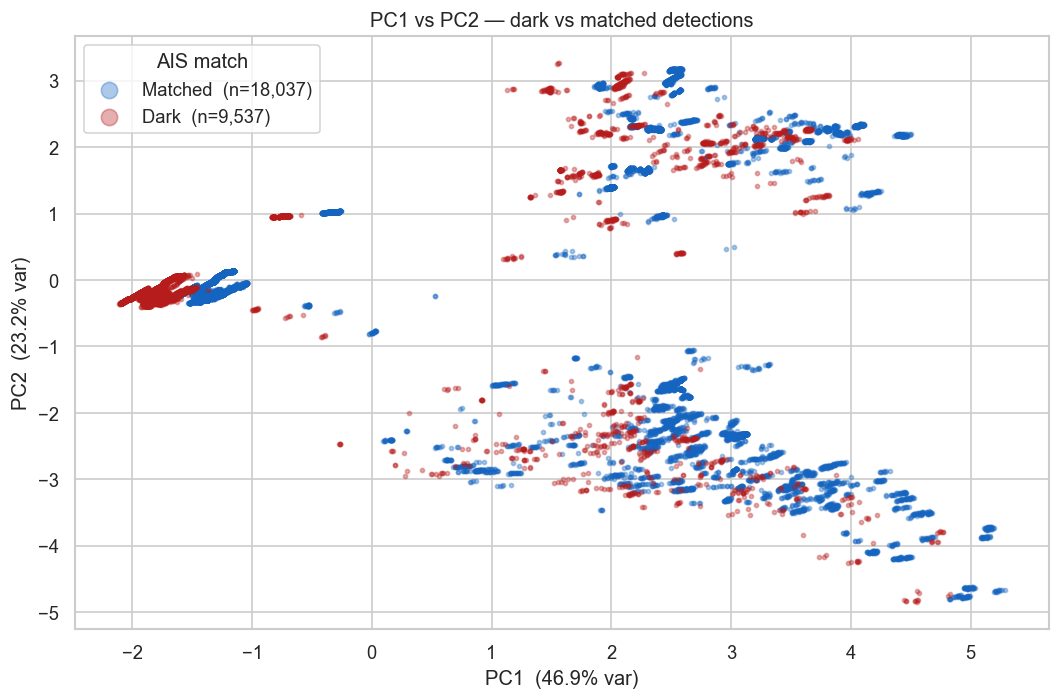

In [31]:
# ── Fit reduced PCA (95% variance) ────────────────────────────────────────────
N_COMP = n_95
pca    = PCA(n_components=N_COMP, random_state=42)
X_pca  = pca.fit_transform(X_scaled)
print(f'Projected shape: {X_pca.shape}')

# ── PC1 vs PC2 scatter coloured by dark / matched ────────────────────────────
PC_X, PC_Y = 1, 2
palette_pca = {'Dark': '#B71C1C', 'Matched': '#1565C0'}

var_x = pca.explained_variance_ratio_[PC_X - 1] * 100
var_y = pca.explained_variance_ratio_[PC_Y - 1] * 100

fig, ax = plt.subplots(figsize=(9, 6))
for status in ['Matched', 'Dark']:
    mask = labels_pca == status
    ax.scatter(X_pca[mask, PC_X - 1], X_pca[mask, PC_Y - 1],
               s=6, alpha=0.35, color=palette_pca[status],
               label=f'{status}  (n={mask.sum():,})')

ax.set(xlabel=f'PC{PC_X}  ({var_x:.1f}% var)',
        ylabel=f'PC{PC_Y}  ({var_y:.1f}% var)',
        title=f'PC{PC_X} vs PC{PC_Y} — dark vs matched detections')
ax.legend(markerscale=4, title='AIS match')
plt.tight_layout()
plt.show()

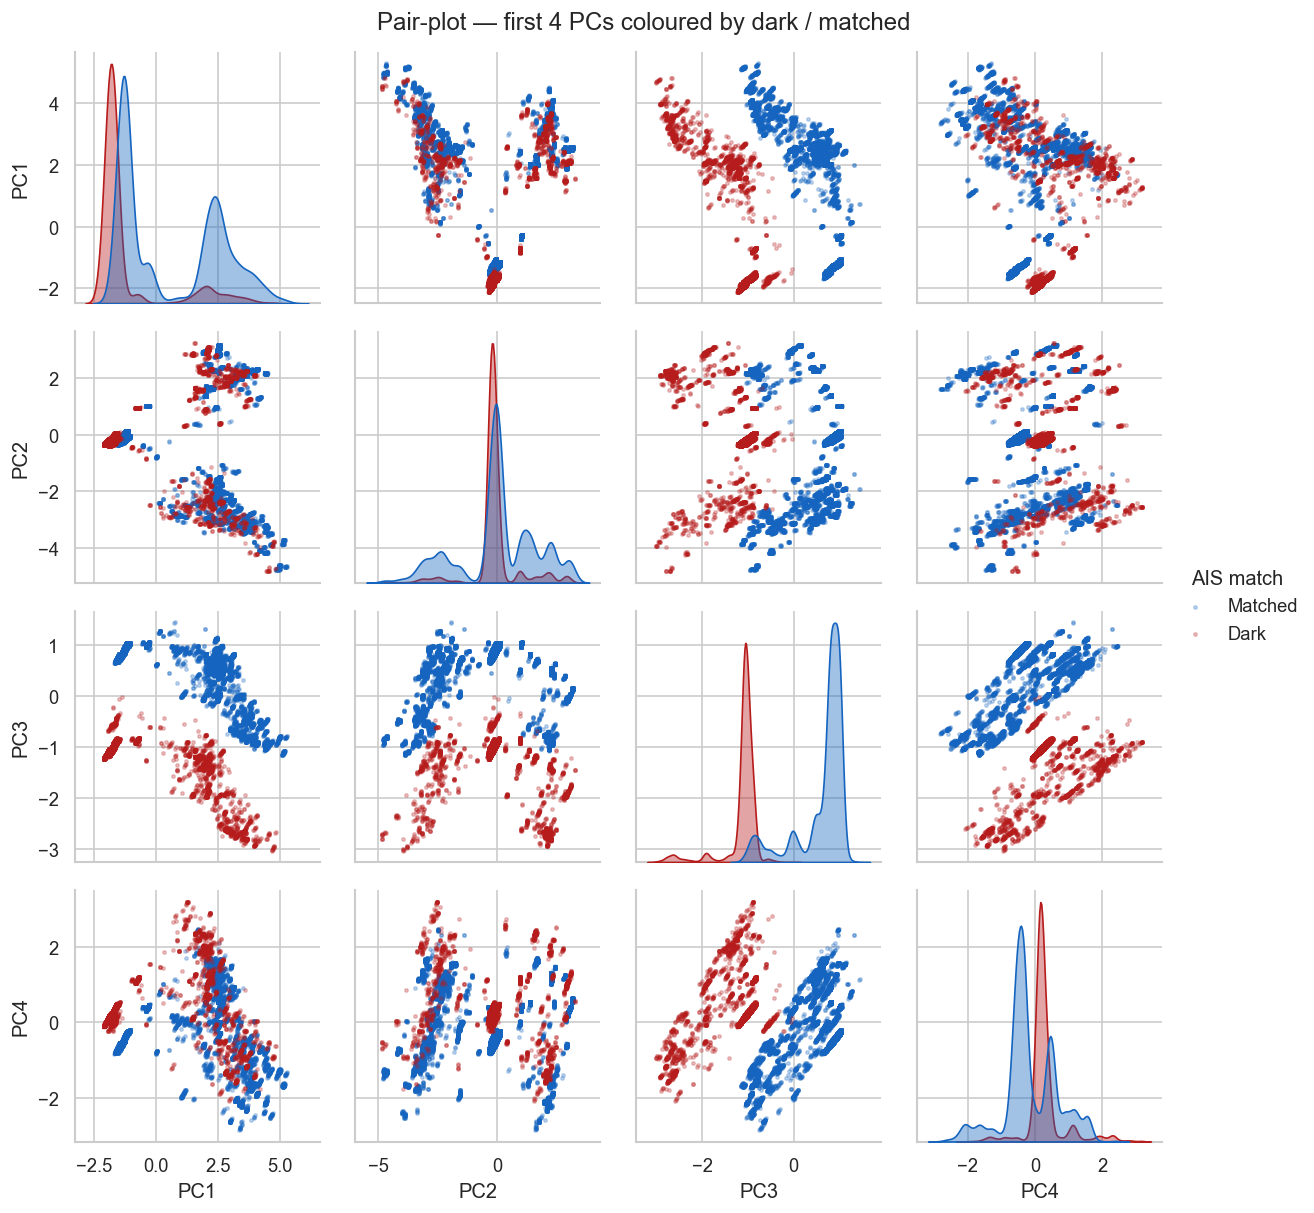

In [32]:
# ── Pair-plot for first 4 PCs ─────────────────────────────────────────────────
n_pair   = min(4, N_COMP)
pair_df  = pd.DataFrame(X_pca[:, :n_pair],
                         columns=[f'PC{i+1}' for i in range(n_pair)])
pair_df['status'] = labels_pca

g = sns.PairGrid(pair_df, hue='status', palette=palette_pca, diag_sharey=False)
g.map_diag(sns.kdeplot, fill=True, alpha=0.4)
g.map_offdiag(plt.scatter, s=4, alpha=0.25)
g.add_legend(title='AIS match')
g.figure.suptitle('Pair-plot — first 4 PCs coloured by dark / matched', y=1.01)
plt.show()

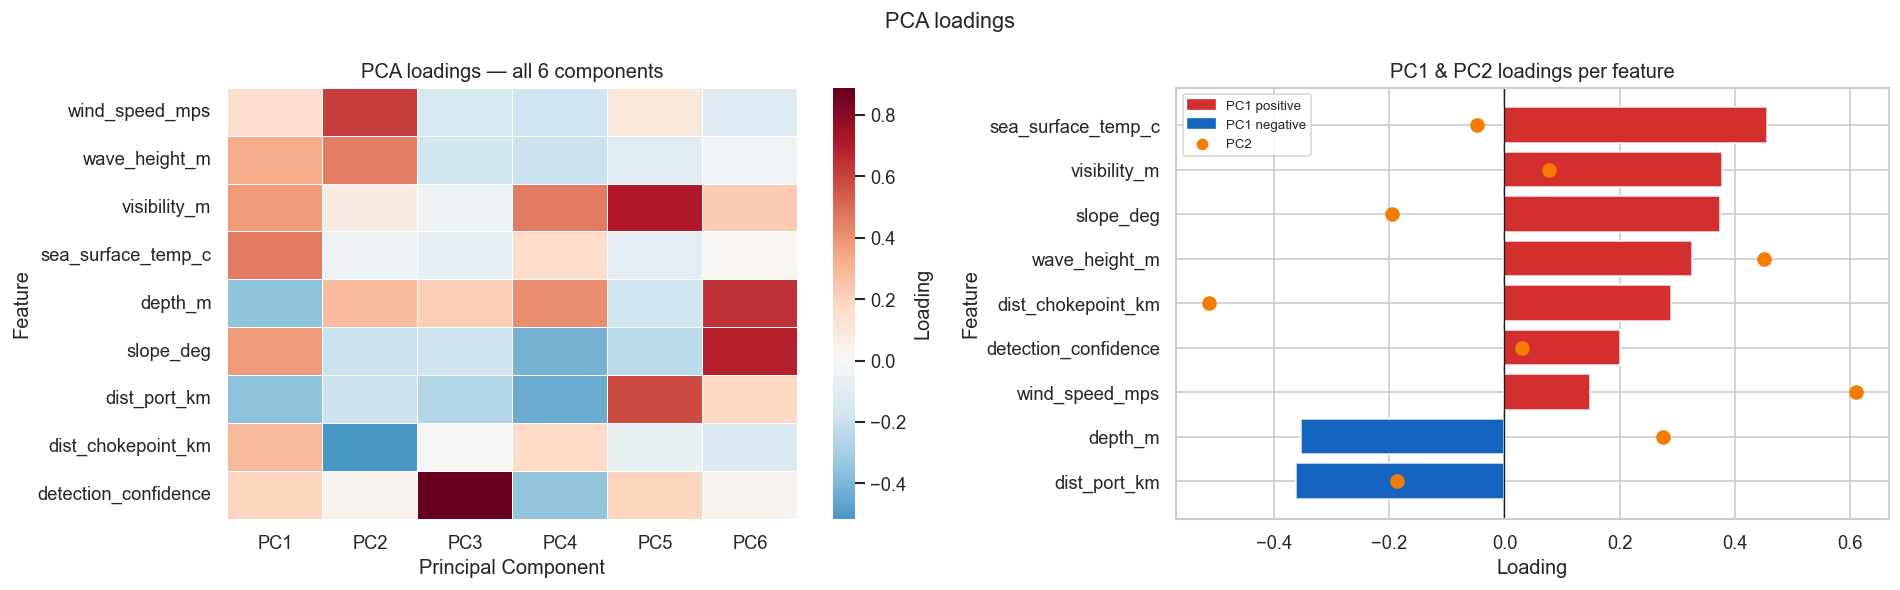


PC1  (46.9% var):
  +█████████████              sea_surface_temp_c  (+0.456)
  +███████████                visibility_m  (+0.378)
  +███████████                slope_deg  (+0.375)
  −██████████                 dist_port_km  (-0.361)

PC2  (23.2% var):
  +██████████████████         wind_speed_mps  (+0.612)
  −███████████████            dist_chokepoint_km  (-0.514)
  +█████████████              wave_height_m  (+0.452)
  +████████                   depth_m  (+0.275)

PC3  (10.4% var):
  +██████████████████████████  detection_confidence  (+0.888)
  −████████                   dist_port_km  (-0.267)
  +██████                     depth_m  (+0.217)
  −█████                      slope_deg  (-0.184)

PC4  (6.5% var):
  +█████████████              visibility_m  (+0.456)
  −█████████████              dist_port_km  (-0.440)
  −████████████               slope_deg  (-0.418)
  +████████████               depth_m  (+0.411)


In [33]:
# ── Loadings heatmap ─────────────────────────────────────────────────────────
loadings = pd.DataFrame(
    pca.components_.T,
    index=PCA_FEATURES,
    columns=[f'PC{i+1}' for i in range(N_COMP)]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(loadings, cmap='RdBu_r', center=0, linewidths=0.4,
            cbar_kws={'label': 'Loading'}, ax=axes[0])
axes[0].set(title=f'PCA loadings — all {N_COMP} components',
             xlabel='Principal Component', ylabel='Feature')

# ── PC1 & PC2 loading bar charts ──────────────────────────────────────────────
for pc_idx, ax in zip([0, 1], [axes[1], None]):
    pc_col   = f'PC{pc_idx + 1}'
    top_load = loadings[pc_col].sort_values()
    colors   = ['#D32F2F' if v > 0 else '#1565C0' for v in top_load]
    axes[1].barh(top_load.index, top_load.values, color=colors, edgecolor='white')
    axes[1].axvline(0, color='k', linewidth=0.8)
    axes[1].set(title=f'PC1 & PC2 loadings per feature',
                 xlabel='Loading', ylabel='Feature')
    break  # only PC1 for clarity; overlay PC2

pc2_load = loadings['PC2'].reindex(top_load.index)
axes[1].scatter(pc2_load.values, range(len(pc2_load)),
                color='#F57C00', s=60, zorder=5, label='PC2')
axes[1].barh(top_load.index, top_load.values,
             color=colors, edgecolor='white', alpha=0.7, label='PC1')
patches = [mpatches.Patch(color='#D32F2F', label='PC1 positive'),
           mpatches.Patch(color='#1565C0', label='PC1 negative'),
           plt.scatter([], [], color='#F57C00', marker='o', label='PC2')]
axes[1].legend(handles=patches, fontsize=8)

plt.suptitle('PCA loadings', fontsize=13)
plt.tight_layout()
plt.show()

# ── Text summary ─────────────────────────────────────────────────────────────
N_TOP = 4
for i in range(min(4, N_COMP)):
    top = loadings[f'PC{i+1}'].abs().nlargest(N_TOP)
    var = pca.explained_variance_ratio_[i] * 100
    print(f'\nPC{i+1}  ({var:.1f}% var):')
    for feat in top.index:
        v    = loadings[f'PC{i+1}'][feat]
        bar  = '█' * int(abs(v) * 30)
        sign = '+' if v > 0 else '−'
        print(f'  {sign}{bar:<25}  {feat}  ({v:+.3f})')

Mean PC scores (centroids):


,PC1,PC2,PC3,PC4,PC5
status,,,,,
Dark,-1.164000,-0.087000,-1.142000,0.279000,-0.125000
Matched,0.616000,0.046000,0.604000,-0.147000,0.066000


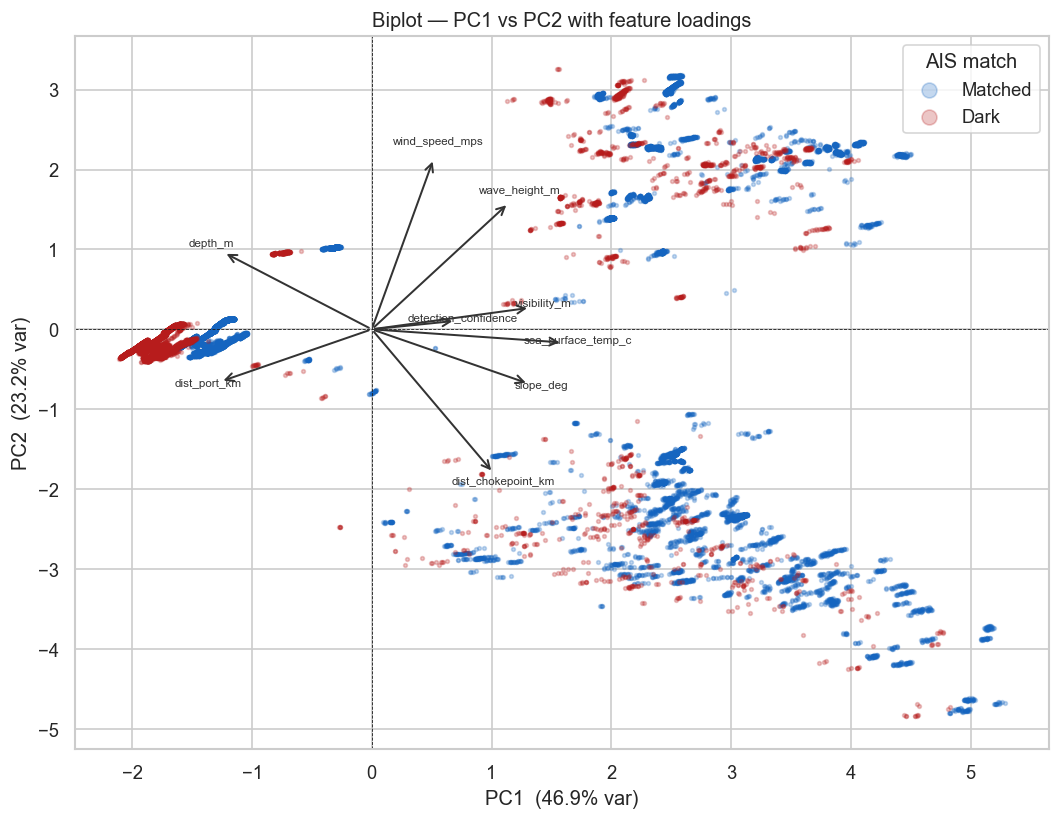

In [34]:
# ── Mean PC scores by dark / matched (centroid separation) ───────────────────
n_c   = min(5, N_COMP)
pc_df = pd.DataFrame(X_pca[:, :n_c],
                     columns=[f'PC{i+1}' for i in range(n_c)])
pc_df['status'] = labels_pca

centroids = pc_df.groupby('status').mean().round(3)
print('Mean PC scores (centroids):')
display(centroids.style.background_gradient(cmap='RdBu_r', axis=None))

# ── Biplot: PC1 vs PC2 with loading arrows ────────────────────────────────────
SCALE = 3.5   # arrow length scale factor

fig, ax = plt.subplots(figsize=(9, 7))
for status in ['Matched', 'Dark']:
    mask = labels_pca == status
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=5, alpha=0.25, color=palette_pca[status], label=status)

for feat in PCA_FEATURES:
    lx = loadings.loc[feat, 'PC1'] * SCALE
    ly = loadings.loc[feat, 'PC2'] * SCALE
    ax.annotate('', xy=(lx, ly), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#333333', lw=1.2))
    ax.text(lx * 1.08, ly * 1.08, feat, fontsize=7, ha='center',
            color='#333333')

ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax.axvline(0, color='k', linewidth=0.5, linestyle='--')
ax.set(xlabel=f'PC1  ({pca.explained_variance_ratio_[0]*100:.1f}% var)',
        ylabel=f'PC2  ({pca.explained_variance_ratio_[1]*100:.1f}% var)',
        title='Biplot — PC1 vs PC2 with feature loadings')
ax.legend(markerscale=4, title='AIS match')
plt.tight_layout()
plt.show()